# Pseudobulk → DESeq2 → GSEA → PROGENy / Hallmark

Aneuploid screen: **euploid vs complex / trisomy / monosomy**, within each cell type.

### Design rationale

| | |
|---|---|
| **Unit of replication** | embryo (`scBC`) × cell type × ploidy — *not* the cell. Cells within an embryo are not independent; single-cell Wilcoxon p-values are strongly anti-conservative. |
| **Model** | `~ embryo + ploidy` — a **paired / within-embryo** design. Each mosaic embryo contributes both euploid and aneuploid pseudobulk samples, so embryo identity absorbs donor/batch effects and the ploidy coefficient is estimated *within* embryo. This is the cleanest possible contrast for a mosaic dataset. |
| **Timepoints** | `scBC` exists only for **day4 / day6** → the paired model runs there. Day1 falls back to a `sample`-level design (Section 10) and should be treated as weaker evidence. |
| **cis vs trans** | Trisomy ⇒ ~1.5×, monosomy ⇒ ~0.5× expression of genes **on the affected chromosome**, purely from gene dosage. That is not a regulatory response. Every DE / GSEA result is therefore reported **twice**: all genes, and *trans*-only (genes on affected chromosomes removed). **The trans result is the biology.** |

### Method choice per question

| Question | Method | Input |
|---|---|---|
| Which genes change? | **DESeq2** (pydeseq2) | pseudobulk raw counts |
| Are pathways coordinately shifted? | **GSEA** (Hallmark) | ranked DESeq2 Wald stat, one list per contrast |
| Which signalling pathways / TFs are active? | **ULM** (PROGENy, CollecTRI) | DESeq2 Wald stat matrix |
| Per-sample pathway activity for plots | **MLM** (PROGENy, Hallmark) | pseudobulk logCPM |

> **ULM vs MLM:** on a *single contrast* (1 × genes vector of t-stats) the covariates are collinear and MLM is unstable — **ULM is the right choice** and is what decoupler's own pseudobulk tutorial uses. MLM is appropriate on the *sample × gene* matrix (many samples), which is what Section 9 does. So: ULM on contrasts, MLM on samples.

## 0. Setup

In [48]:
# Env: py_decoupler
# Requires: pydeseq2 (pip install pydeseq2), decoupler >= 2.0, scanpy, gseapy (optional)

import os, sys, re, warnings
from datetime import date

import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

warnings.simplefilter("ignore", FutureWarning)

mpl.rcParams["pdf.fonttype"] = 42      # editable text in Illustrator
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["svg.fonttype"] = "none"
sc.settings.verbosity = 1

print("decoupler", dc.__version__, "| scanpy", sc.__version__)
f"Last execution: {date.today()}"

decoupler 2.1.1 | scanpy 1.11.1


'Last execution: 2026-07-13'

In [49]:
# ---- paths -------------------------------------------------------------
base_dir   = "/nfs/team292/rs40/projects/Aneuploid_screen_v2"
h5ad_in    = f"{base_dir}/processed_data/3_scanpy_integration/integrated_sub_adata.h5ad"
ploidy_csv = f"{base_dir}/processed_data/7_2_xclone/cell_karyotype_scploid.csv"

output_dir = f"{base_dir}/processed_data/12_pseudobulk_deseq2_gsea"
fig_dir    = f"{output_dir}/figures"
tab_dir    = f"{output_dir}/tables"
for d in (output_dir, fig_dir, tab_dir):
    os.makedirs(d, exist_ok=True)

sc.settings.figdir = fig_dir

# ---- analysis config ---------------------------------------------------
COUNTS_LAYER   = "counts"          # raw integer counts  <-- REQUIRED by DESeq2
CELLTYPE_COL   = "celltype_coarse"   # EPI / TE / unknown
PLOIDY_COL     = "ploidy"
KARYO_COL      = "karyotype"
TIMEPOINTS     = [ "day4", "day6"]  # timepoints with embryo annotation

REFERENCE      = "euploid"
TEST_GROUPS    = ["complex", "trisomy", "monosomy"]

# pseudobulk QC thresholds (per pseudobulk sample)
MIN_CELLS      = 1       # >= this many cells to form a pseudobulk sample
MIN_COUNTS     = 1000    # >= this many total counts
MIN_SAMPLES_PER_GROUP = 3 # >= this many embryos per side of the contrast

# significance
PADJ_CUT, LFC_CUT = 0.05, 0.5

palette = {"euploid": "#C5C5C5", "trisomy": "#F26B3B",
           "monosomy": "#109E9D", "complex": "#662C91"}



PAIRED = False

In [50]:
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Load & harmonise labels

Two things to fix before anything else:

1. Your notebook uses **`diploid`** (from scploid) and **`euploid`** (in derived columns) interchangeably. Here everything is normalised to **`euploid`**.
2. pydeseq2 mangles factor level names containing `_` when building contrasts. Column names and level names are kept `_`-free where they enter the design.

In [51]:
adata = sc.read_h5ad(h5ad_in)

# ---- barcode / embryo assignment ---------------------------------------
BC_path = "/nfs/team292/rs40/projects/Aneuploid_screen/processed_data/barcode/BC_df.csv"
BC_df = pd.read_csv(BC_path)

# keep only what we need, avoid dragging in duplicate columns
#BC_df = BC_df[["cell.ID_", "filtered_feature_call", 'dataset']].drop_duplicates("cell.ID_")
BC_df["cell.ID_"] = BC_df["cell.ID_"] + "-1_" + BC_df['dataset']
BC_df = BC_df[["cell.ID_", "filtered_feature_call"]].drop_duplicates("cell.ID_")


# --- merge WITHOUT losing the AnnData index ---
obs = adata.obs.copy()
obs_index = obs.index                      # preserve it
obs = pd.merge(obs, BC_df, on="cell.ID_", how="left", suffixes=("", "_2"))
obs.index = obs_index                      # restore it
assert (obs.index == adata.obs_names).all(), "obs index misaligned after merge"
adata.obs = obs

print("cells with a feature call:",
      adata.obs["filtered_feature_call"].notna().sum(), "/", adata.n_obs)

cells with a feature call: 24225 / 38655


In [52]:
# ---- sanity check: raw counts present and actually integer -------------
assert COUNTS_LAYER in adata.layers, f"missing layer '{COUNTS_LAYER}'"

X = adata.layers[COUNTS_LAYER]
sample_vals = (X[:50].data if hasattr(X, "data") else np.asarray(X[:50])).ravel()
sample_vals = sample_vals[:1000]
is_int = np.allclose(sample_vals, np.round(sample_vals))
print(f"counts layer looks like integers: {is_int}")
print(f"max value: {sample_vals.max():.2f}  (log-transformed data would be small, e.g. < 15)")
assert is_int, "DESeq2 needs RAW integer counts, not log/normalised values."

counts layer looks like integers: True
max value: 124.00  (log-transformed data would be small, e.g. < 15)


In [53]:
# ---- attach ploidy calls (index-preserving) -----------------------------
ploidy_df = pd.read_csv(ploidy_csv, index_col=0)

# what the file brings in besides the join key
print("ploidy_df columns:", list(ploidy_df.columns))
ploidy_df = ploidy_df.drop_duplicates("cell").set_index("cell")

# avoid silent collisions if adata.obs already carries any of these names
clash = [c for c in ploidy_df.columns if c in adata.obs.columns]
if clash:
    print(f"dropping pre-existing obs columns that would collide: {clash}")
    adata.obs = adata.obs.drop(columns=clash)

# join by MAPPING through the key column -- index never moves
key = adata.obs["cell.ID_"].astype(str)
for col in ploidy_df.columns:                       # 'ploidy', 'karyotype', ...
    adata.obs[col] = key.map(ploidy_df[col]).values

assert (adata.obs.index == adata.obs_names).all(), "obs index misaligned"
print(f"ploidy assigned for {adata.obs['ploidy'].notna().sum():,} / {adata.n_obs:,} cells")

ploidy_df columns: ['cell', 'karyotype', 'ploidy', 'num_gain_chr', 'num_loss_chr', 'num_chr', 'num_abnormal_chr']
ploidy assigned for 38,655 / 38,655 cells


In [54]:
# ---- harmonise ploidy --------------------------------------------------
# adata with ploidy info
adata.obs["ploidy"] = pd.Categorical(
    adata.obs["ploidy"].astype(str).replace({"diploid": "euploid"}),
    categories=["euploid", "trisomy", "monosomy", "complex"],
    ordered=True,
)

# anything not in the 4 expected levels became NaN -- make sure that's only true NaNs
raw = adata.obs["ploidy"].astype(str)
unexpected = set(raw.unique()) - {"euploid", "trisomy", "monosomy", "complex", "nan", "None"}
if unexpected:
    print(f">>> WARNING: unrecognised ploidy labels dropped to NaN: {unexpected}")

print(adata.obs["ploidy"].value_counts(dropna=False))
# ---- cell type ---------------------------------------------------------
adata.obs["celltype"] = adata.obs[CELLTYPE_COL].astype(str)

# ---- embryo = dataset + feature call ------------------------------------
adata.obs["scBC"] = (
    adata.obs["dataset"].astype(str) + "_" + adata.obs["filtered_feature_call"].astype(str)
)

#drop multiplets and unassigned cells -- a cell called for >1 barcode has no single embryo
is_multiplet = adata.obs["filtered_feature_call"].astype(str).str.contains(r"\|", na=False)
bad = (
    #adata.obs["filtered_feature_call"].isna()
     adata.obs["filtered_feature_call"].astype(str).isin(["nan", "None", "", "Multiplet", "Blank", "fail"])
    | is_multiplet
)
adata.obs.loc[bad, "scBC"] = np.nan
print(f"dropped {bad.sum():,} cells with no unambiguous embryo assignment "
      f"({is_multiplet.sum():,} multiplets)")

# pydeseq2 splits contrast strings on '_', so keep factor LEVELS underscore-free
adata.obs["embryo"] = adata.obs["scBC"].str.replace("_", ".", regex=False)

print(adata.obs.groupby("timepoint", observed=True)["embryo"]
      .agg(n_embryos="nunique", frac_assigned=lambda s: s.notna().mean()))

ploidy
euploid     27380
complex      5842
trisomy      3298
monosomy     2135
Name: count, dtype: int64
dropped 18,386 cells with no unambiguous embryo assignment (0 multiplets)
           n_embryos  frac_assigned
timepoint                          
day1               0       0.000000
day4             433       0.757223
day6             361       0.519811


In [55]:
# ---- the working object: timepoints WITH embryo annotation -------------
keep = (
    adata.obs["timepoint"].isin(TIMEPOINTS)
    & adata.obs["embryo"].notna()
    & adata.obs["ploidy"].notna()
    & adata.obs["celltype"].notna()
)
adata_pb = adata[keep].copy()
print(f"{adata_pb.n_obs:,} / {adata.n_obs:,} cells retained")

# ---- how many embryos actually contribute BOTH euploid and aneuploid? --
# (this is what powers the paired design)
tab = (
    adata_pb.obs
    .groupby(["celltype", "embryo", "ploidy"], observed=True)
    .size().unstack(fill_value=0)
)
tab["n_ploidy_groups_with>=MIN_CELLS"] = (tab >= MIN_CELLS).sum(axis=1)
tab.head(30)

20,269 / 38,655 cells retained


ploidy                                     euploid  trisomy  monosomy  \
celltype embryo                                                         
EPI      Embryo-Imp15265940.pooled.BC.102        1        0         0   
         Embryo-Imp15265940.pooled.BC.104        1        0         0   
         Embryo-Imp15265940.pooled.BC.115        1        0         0   
         Embryo-Imp15265940.pooled.BC.151        1        0         0   
         Embryo-Imp15265940.pooled.BC.164        1        0         0   
         Embryo-Imp15265940.pooled.BC.165        1        0         0   
         Embryo-Imp15265940.pooled.BC.19         1        0         0   
         Embryo-Imp15265940.pooled.BC.23         0        0         0   
         Embryo-Imp15265940.pooled.BC.26         1        0         0   
         Embryo-Imp15265940.pooled.BC.27         0        0         0   
         Embryo-Imp15265940.pooled.BC.29         1        0         0   
         Embryo-Imp15265940.pooled.BC.39         1        0         0   
         Embryo-Imp15265940.pooled.BC.4          1        0         0   
         Embryo-Imp15265940.pooled.BC.43         1        0         0   
         Embryo-Imp15265940.pooled.BC.48         2        0         0   
         Embryo-Imp15265940.pooled.BC.50         1        0         0   
         Embryo-Imp15265940.pooled.BC.52         2        0         0   
         Embryo-Imp15265940.pooled.BC.53         2        0         0   
         Embryo-Imp15265940.pooled.BC.59         1        0         0   
         Embryo-Imp15265940.pooled.BC.65         1        0         0   
         Embryo-Imp15265940.pooled.BC.72         0        0         0   
         Embryo-Imp15265940.pooled.BC.85         1        1         0   
         Embryo-Imp15265941.pooled.BC.113        1        0         0   
         Embryo-Imp15265941.pooled.BC.125        2        0         1   
         Embryo-Imp15265941.pooled.BC.133        1        0         0   
         Embryo-Imp15265941.pooled.BC.134        2        0         0   
         Embryo-Imp15265941.pooled.BC.140        1        0         0   
         Embryo-Imp15265941.pooled.BC.143        0        0         0   
         Embryo-Imp15265941.pooled.BC.146        1        0         0   
         Embryo-Imp15265941.pooled.BC.150        1        0         0   

ploidy                                     complex  \
celltype embryo                                      
EPI      Embryo-Imp15265940.pooled.BC.102        0   
         Embryo-Imp15265940.pooled.BC.104        0   
         Embryo-Imp15265940.pooled.BC.115        0   
         Embryo-Imp15265940.pooled.BC.151        0   
         Embryo-Imp15265940.pooled.BC.164        0   
         Embryo-Imp15265940.pooled.BC.165        0   
         Embryo-Imp15265940.pooled.BC.19         0   
         Embryo-Imp15265940.pooled.BC.23         1   
         Embryo-Imp15265940.pooled.BC.26         0   
         Embryo-Imp15265940.pooled.BC.27         1   
         Embryo-Imp15265940.pooled.BC.29         0   
         Embryo-Imp15265940.pooled.BC.39         0   
         Embryo-Imp15265940.pooled.BC.4          0   
         Embryo-Imp15265940.pooled.BC.43         0   
         Embryo-Imp15265940.pooled.BC.48         0   
         Embryo-Imp15265940.pooled.BC.50         0   
         Embryo-Imp15265940.pooled.BC.52         0   
         Embryo-Imp15265940.pooled.BC.53         0   
         Embryo-Imp15265940.pooled.BC.59         0   
         Embryo-Imp15265940.pooled.BC.65         0   
         Embryo-Imp15265940.pooled.BC.72         1   
         Embryo-Imp15265940.pooled.BC.85         0   
         Embryo-Imp15265941.pooled.BC.113        0   
         Embryo-Imp15265941.pooled.BC.125        0   
         Embryo-Imp15265941.pooled.BC.133        0   
         Embryo-Imp15265941.pooled.BC.134        0   
         Embryo-Imp15265941.pooled.BC.140        0   
         Embryo-Imp15265941.pooled.BC.143        1   
         Embryo-Imp15265941.pooled.BC.146  

In [56]:
# Cells per contrast cell -- read this table before trusting any result below.
counts_tab = (
    adata_pb.obs
    .groupby(["timepoint", "celltype", "ploidy"], observed=True)
    .agg(n_cells=("ploidy", "size"), n_embryos=("embryo", "nunique"))
    .reset_index()
)
counts_tab.to_csv(f"{tab_dir}/group_sizes.csv", index=False)
counts_tab

,timepoint,celltype,ploidy,n_cells,n_embryos
0,day4,EPI,euploid,50,40
1,day4,EPI,trisomy,5,5
2,day4,EPI,monosomy,4,4
3,day4,EPI,complex,6,6
4,day4,TE,euploid,2,2
5,day4,unspecified,euploid,8687,393
6,day4,unspecified,trisomy,741,278
7,day4,unspecified,monosomy,705,265
8,day4,unspecified,complex,1699,383
9,day6,EPI,euploid,344,115


## 2. Chromosome annotation → the *cis* / *trans* split

**This is the single most important addition to your analysis.**

A trisomy-21 cell has ~1.5× expression of *every* chr21 gene. If you run DE and GSEA
naively, the top hits are just chr21 genes, and any Hallmark set that happens to be
chromosome-biased will be "significant" as a pure dosage artifact — nothing to do with
an aneuploidy *response*.

So for each contrast we define:

* **cis genes** — on chromosomes recurrently altered in the test group (derived from the
  `karyotype` strings of the cells in that group). Expected to move; a *positive control*.
* **trans genes** — everything else. **This is where the elimination / stress biology lives.**

In [57]:
# ---- gene -> chromosome -------------------------------------------------
# Reuse adata.var if it already carries chromosome info; else query Ensembl.
chrom_col = next((c for c in ["chromosome", "chr", "chromosome_name", "seqname"]
                  if c in adata.var.columns), None)

if chrom_col is None:
    print("No chromosome column in adata.var -- querying Ensembl BioMart ...")
    annot = sc.queries.biomart_annotations(
        "hsapiens",
        ["external_gene_name", "chromosome_name"],
        use_cache=True,
    )
    annot = annot[annot["chromosome_name"].isin([str(i) for i in range(1, 23)] + ["X", "Y"])]
    gene2chr = dict(zip(annot["external_gene_name"], annot["chromosome_name"]))
else:
    gene2chr = adata.var[chrom_col].astype(str).to_dict()

gene2chr = {g: str(c).replace("chr", "") for g, c in gene2chr.items()}
adata_pb.var["chromosome"] = pd.Series(adata_pb.var_names.map(gene2chr).values,
                                       index=adata_pb.var_names)
print(f"chromosome assigned for {adata_pb.var['chromosome'].notna().sum():,} / {adata_pb.n_vars:,} genes")
adata_pb.var["chromosome"].value_counts().head()

No chromosome column in adata.var -- querying Ensembl BioMart ...
chromosome assigned for 23,002 / 33,540 genes


chromosome
1     2325
2     1536
19    1501
3     1359
11    1356
Name: count, dtype: int64

In [58]:
def affected_chromosomes(obs, group, karyo_col=KARYO_COL, min_frac=0.25):
    """Chromosomes altered in >= min_frac of the cells of `group`.

    Parses karyotype strings like '13+, 22+, 12-' -> {'13','22','12'}.
    Used to define the cis set to EXCLUDE for the trans analysis.
    """
    sub = obs.loc[obs["ploidy"] == group, karyo_col].dropna().astype(str)
    if len(sub) == 0:
        return set()
    hits = sub.apply(lambda s: set(re.findall(r"(\d+|X|Y)[+-]", s)))
    exploded = pd.Series([c for s in hits for c in s])
    freq = exploded.value_counts() / len(sub)
    return set(freq[freq >= min_frac].index)


# Inspect what each ploidy class actually carries
for g in TEST_GROUPS:
    chroms = affected_chromosomes(adata_pb.obs, g)
    print(f"{g:>9}: recurrently affected chromosomes -> {sorted(chroms) if chroms else '(none >=25%)'}")

  complex: recurrently affected chromosomes -> ['11', '12', '17', '2', '3', '4', '5', '7', '8', '9']
  trisomy: recurrently affected chromosomes -> ['11']
 monosomy: recurrently affected chromosomes -> ['11']


> **Note on `complex`:** by definition these cells carry many, heterogeneous alterations, so no
> single chromosome may pass the 25% threshold. If `complex` returns few/no chromosomes,
> lower `min_frac`, or use the union of all chromosomes appearing in >10% of cells — and
> interpret the complex contrast with the chromosome-coloured volcano (Section 6) firmly in view.

## 3. Pseudobulk

Aggregate **raw counts** by `embryo × celltype × ploidy`. Each resulting pseudobulk sample is
one replicate. Samples built from too few cells / counts are dropped — they are pure noise
and will destabilise dispersion estimation.

In [59]:
import inspect
print(inspect.signature(dc.pp.pseudobulk))

(adata: anndata._core.anndata.AnnData, sample_col: str, groups_col: str | None, layer: str | None = None, raw: bool = False, empty: bool = False, mode: str | collections.abc.Callable | dict = 'sum', skip_checks: bool = False, bsize: int = 250000, verbose: bool = False) -> anndata._core.anndata.AnnData


In [60]:
adata_pb.obs["pb_group"] = (
    adata_pb.obs["timepoint"].astype(str) + "|"
    + adata_pb.obs["celltype"].astype(str) + "|"
    + adata_pb.obs["ploidy"].astype(str)
)

pdata = dc.pp.pseudobulk(
    adata_pb, sample_col="embryo", groups_col="pb_group",
    layer=COUNTS_LAYER, mode="sum", verbose=False,
)

before = pdata.n_obs


dc.pp.filter_samples(pdata, min_cells=MIN_CELLS, min_counts=MIN_COUNTS)
print(f"pseudobulk samples: {before} -> {pdata.n_obs}")

# carry the split fields through
pdata.obs[["timepoint", "celltype", "ploidy"]] = (
    pdata.obs["pb_group"].str.split("|", expand=True).values
)
pdata.obs["ploidy"] = pd.Categorical(pdata.obs["ploidy"],
                                     categories=["euploid"] + TEST_GROUPS, ordered=True)
pdata.obs["embryo"] = pdata.obs["embryo"].astype(str)

# a pseudobulk sample is now: embryo x timepoint x celltype x ploidy
pdata.obs.groupby(["timepoint", "celltype", "ploidy"], observed=True).size()

pseudobulk samples: 16674 -> 2439


timepoint  celltype     ploidy  
day4       EPI          euploid      40
                        complex       6
                        trisomy       5
                        monosomy      4
           TE           euploid       2
           unspecified  euploid     393
                        complex     383
                        trisomy     278
                        monosomy    265
day6       EPI          euploid     115
                        complex      21
                        trisomy      41
                        monosomy     11
           TE           euploid     178
                        complex      27
                        trisomy      67
                        monosomy     26
           unspecified  euploid     157
                        complex     155
                        trisomy     138
                        monosomy    127
dtype: int64

2026-07-13 22:42:21 | [INFO] maxp pruned
2026-07-13 22:42:21 | [INFO] cmap pruned
2026-07-13 22:42:21 | [INFO] kern dropped
2026-07-13 22:42:21 | [INFO] post pruned
2026-07-13 22:42:21 | [INFO] FFTM dropped
2026-07-13 22:42:21 | [INFO] GPOS pruned
2026-07-13 22:42:21 | [INFO] GSUB pruned
2026-07-13 22:42:21 | [INFO] glyf pruned
2026-07-13 22:42:21 | [INFO] Added gid0 to subset
2026-07-13 22:42:21 | [INFO] Added first four glyphs to subset
2026-07-13 22:42:21 | [INFO] Closing glyph list over 'MATH': 36 glyphs before
2026-07-13 22:42:21 | [INFO] Glyph names: ['.notdef', '.null', 'E', 'I', 'P', 'T', 'a', 'b', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'y', 'zero']
2026-07-13 22:42:21 | [INFO] Glyph IDs:   [0, 1, 2, 3, 19, 20, 21, 22, 23, 24, 25, 40, 44, 51, 55, 68, 69, 70, 71, 72, 73, 74, 75, 76, 78, 79, 80, 81, 82, 83, 85, 86, 87, 88, 91, 92]
2026-07-13 22:42:21 | [IN

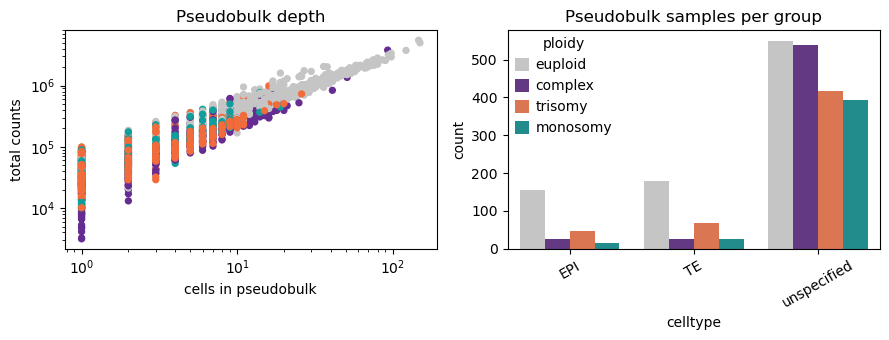

In [61]:
# Pseudobulk QC: library size vs number of cells. Points hugging the origin are
# the samples MIN_CELLS/MIN_COUNTS is meant to remove.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].scatter(pdata.obs["psbulk_cells"], pdata.obs["psbulk_counts"],
                c=[palette[p] for p in pdata.obs["ploidy"]], s=18)
axes[0].set(xscale="log", yscale="log", xlabel="cells in pseudobulk", ylabel="total counts")
axes[0].set_title("Pseudobulk depth")

sns.countplot(data=pdata.obs, x="celltype", hue="ploidy", palette=palette, ax=axes[1])
axes[1].set_title("Pseudobulk samples per group")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(f"{fig_dir}/pseudobulk_QC.pdf", bbox_inches="tight")
plt.show()

... storing 'embryo' as categorical
... storing 'timepoint' as categorical
... storing 'celltype' as categorical
... storing 'chromosome' as categorical
/tmp/ipykernel_2454475/2961236380.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
2026-07-13 22:42:56 | [INFO] maxp pruned
2026-07-13 22:42:56 | [INFO] cmap pruned
2026-07-13 22:42:56 | [INFO] kern dropped
2026-07-13 22:42:56 | [INFO] post pruned
2026-07-13 22:42:56 | [INFO] FFTM dropped
2026-07-13 22:42:56 | [INFO] GPOS pruned
2026-07-13 22:42:56 | [INFO] GSUB pruned
2026-07-13 22:42:56 | [INFO] glyf pruned
2026-07-13 22:42:56 | [INFO] Added gid0 to subset
2026-07-13 22:42:56 | [INFO] Added first four glyphs to subset
2026-07-13 22:42:56 | [INFO] Closing glyph list over 'MATH': 39 glyphs before
2026-07-13 22:42:56 | [INFO] Glyph names: ['.notdef', '.null', 'B', 'C', 'E', 'I', 'P', 'T', 'b', 'c', 'd', 'e', 'eight', 'f', 'five'

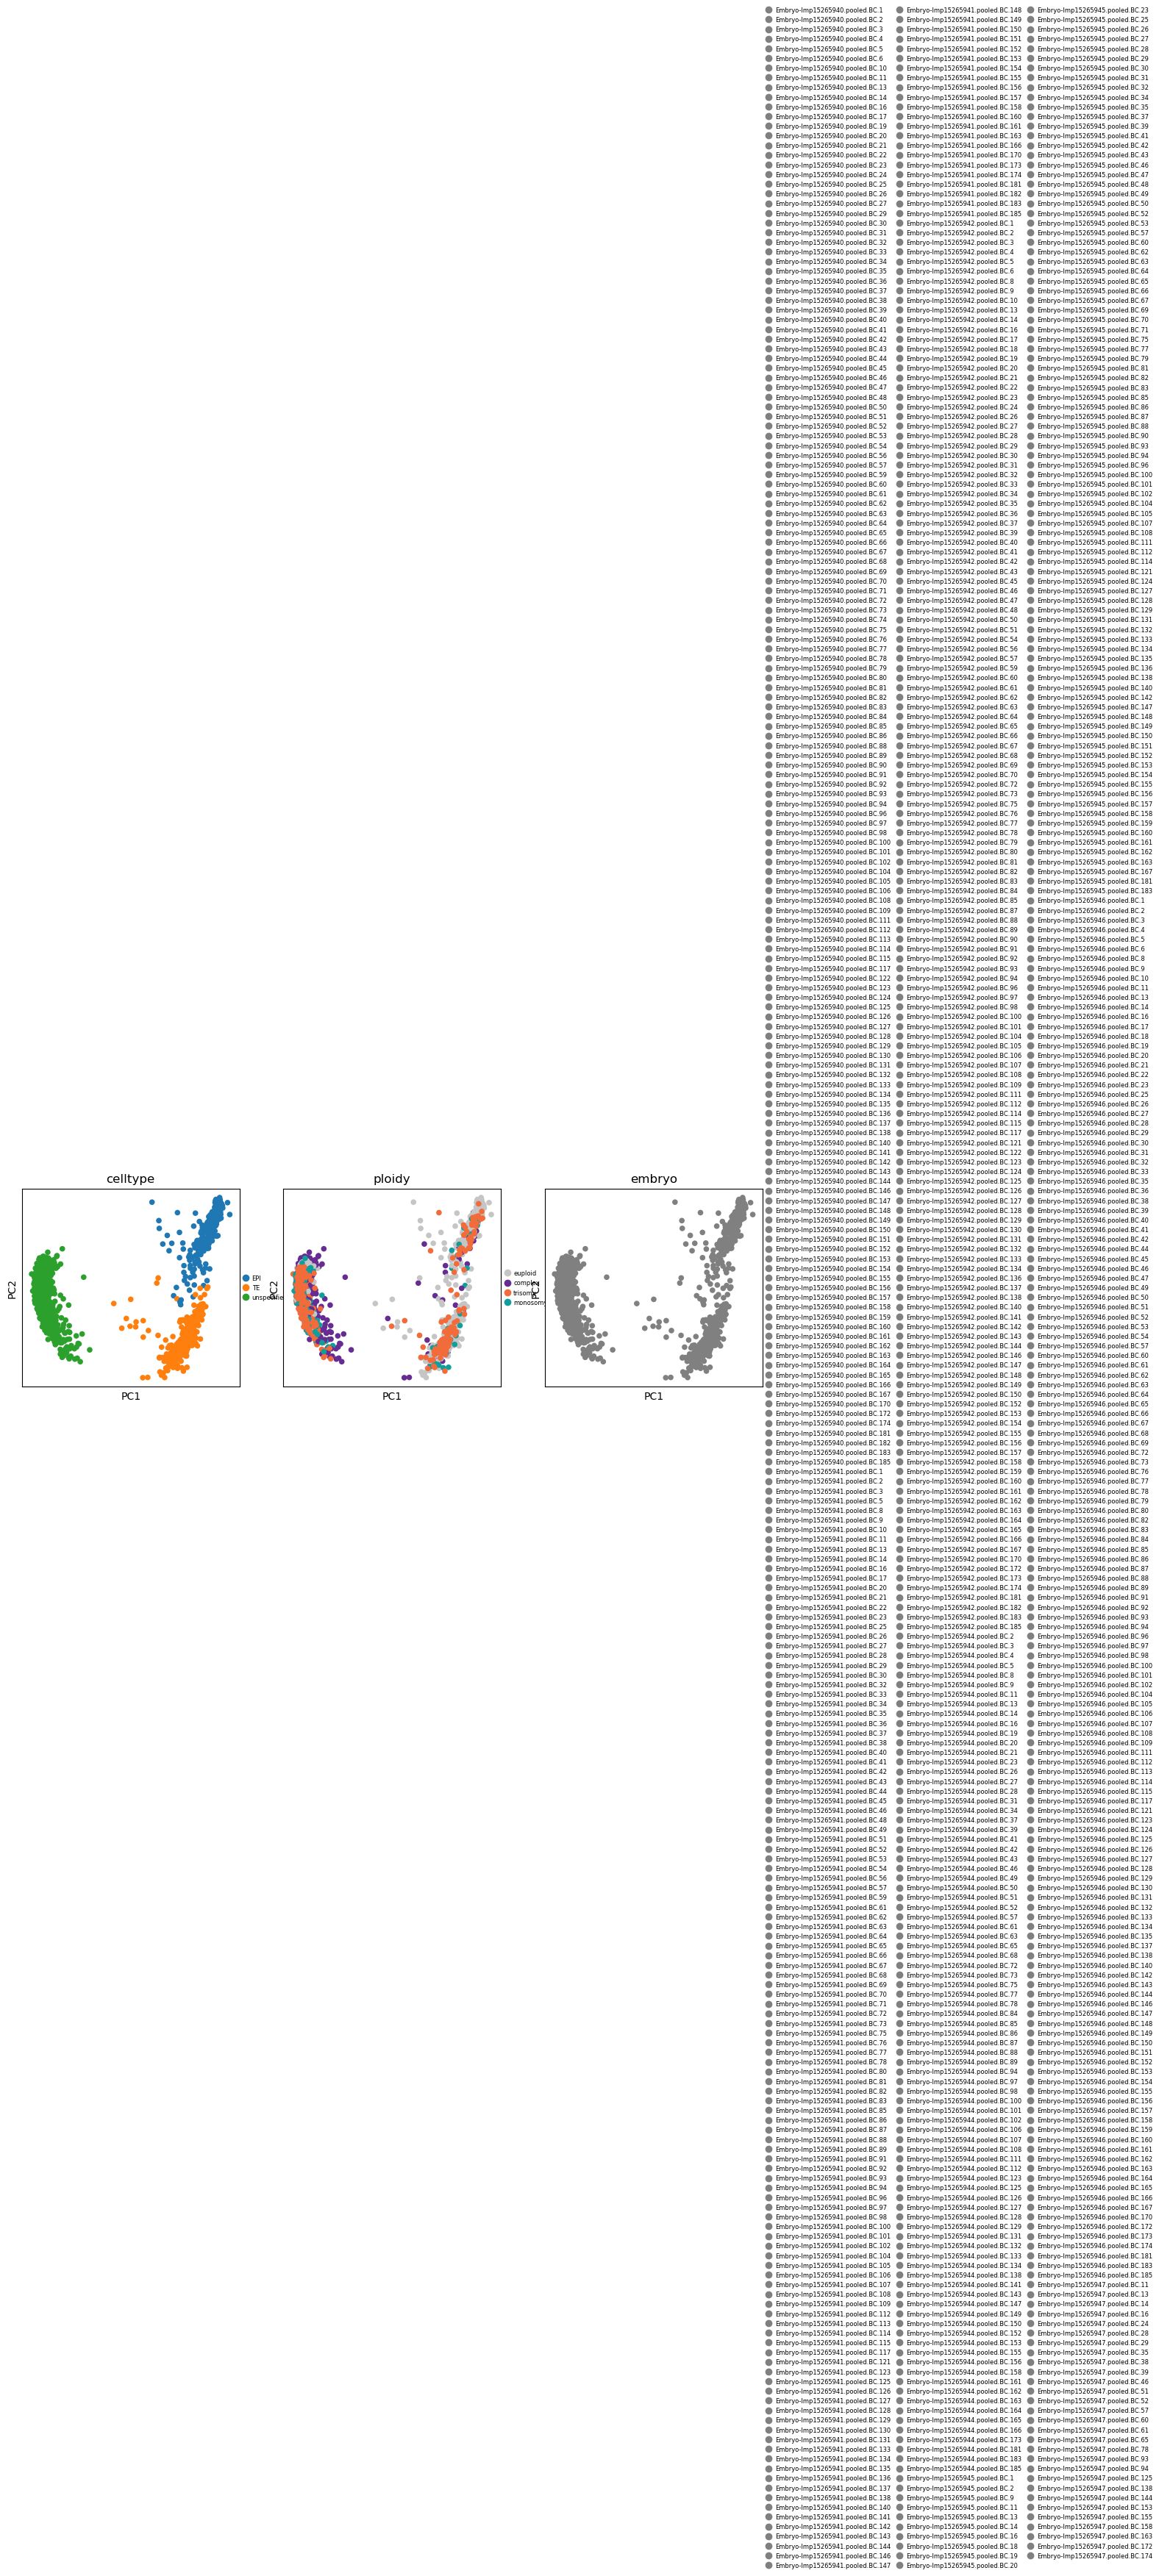

In [62]:
# PCA of pseudobulk samples -- does variation track embryo, ploidy, or cell type?
# If PC1/PC2 are dominated by EMBRYO, that vindicates the paired ~embryo + ploidy design.
pp = pdata.copy()
dc.pp.filter_by_expr(pp, group="pb_group", min_count=10, min_total_count=15)
sc.pp.normalize_total(pp, target_sum=1e6)
sc.pp.log1p(pp)
sc.pp.pca(pp, n_comps=min(10, pp.n_obs - 1))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, ["celltype", "ploidy", "embryo"]):
    sc.pl.pca(pp, color=col, ax=ax, show=False, size=120,
              palette=palette if col == "ploidy" else None,
              legend_fontsize=6, title=col)
plt.tight_layout()
plt.savefig(f"{fig_dir}/pseudobulk_PCA.pdf", bbox_inches="tight")
plt.show()

## 4. DESeq2: `~ embryo + ploidy`, per cell type

For each cell type and each test group (complex / trisomy / monosomy) we fit DESeq2 on the
pseudobulk samples of `{euploid, test_group}` with embryo as a blocking factor.

**Guard rails built in:**
* the contrast is skipped unless ≥ `MIN_SAMPLES_PER_GROUP` embryos are present on *both* sides;
* the paired term is dropped automatically if no embryo contributes both ploidy classes
  (otherwise `embryo` and `ploidy` are collinear and the model is not identifiable) — this is
  reported per contrast so you know which results are paired and which are not.

In [63]:
def run_deseq(pdata, timepoint, celltype, test_group, reference=REFERENCE,
              min_n=MIN_SAMPLES_PER_GROUP, n_cpus=4):
    """DESeq2 on pseudobulk for one timepoint / celltype / contrast."""
    info = {"timepoint": timepoint, "celltype": celltype, "group": test_group}

    sub = pdata[(pdata.obs["timepoint"] == timepoint)
                & (pdata.obs["celltype"] == celltype)
                & (pdata.obs["ploidy"].isin([reference, test_group]))].copy()
    sub.obs["ploidy"] = sub.obs["ploidy"].astype(str)

    n_ref  = int((sub.obs["ploidy"] == reference).sum())
    n_test = int((sub.obs["ploidy"] == test_group).sum())
    info.update(n_ref=n_ref, n_test=n_test)

    if n_ref < min_n or n_test < min_n:
        info["status"] = f"SKIPPED: n_ref={n_ref}, n_test={n_test} (< {min_n})"
        return None, info

    # paired term identifiable only if some embryo spans both ploidy classes
    per_embryo = sub.obs.groupby("embryo", observed=True)["ploidy"].nunique()
    can_pair = (per_embryo >= 2).sum() >= 1 and sub.obs["embryo"].nunique() > 1

    paired = PAIRED and can_pair          # <-- only pairs if you ask for it AND it's estimable
    design = ["embryo", "ploidy"] if paired else ["ploidy"]

    info["paired"] = bool(paired)
    info["could_have_paired"] = bool(can_pair)     # so the log still tells you what you gave up
    info["n_embryos"] = int(sub.obs["embryo"].nunique())
    info["n_paired_embryos"] = int((per_embryo >= 2).sum())

    dc.pp.filter_by_expr(sub, group="ploidy", min_count=10, min_total_count=15)
    info["n_genes_tested"] = int(sub.n_vars)

    try:
        try:                                        # pydeseq2 >= 0.5
            dds = DeseqDataSet(adata=sub, design="~" + " + ".join(design),
                               refit_cooks=False, n_cpus=n_cpus, quiet=True)
        except TypeError:                           # pydeseq2 0.4.x
            dds = DeseqDataSet(adata=sub, design_factors=design,
                               refit_cooks=False, n_cpus=n_cpus, quiet=True)
        dds.deseq2()
        stat = DeseqStats(dds, contrast=["ploidy", test_group, reference],
                          n_cpus=n_cpus, quiet=True)
        stat.summary()
        res = stat.results_df.copy()
    except Exception as e:
        info["status"] = f"FAILED: {type(e).__name__}: {e}"
        return None, info

    res["timepoint"], res["celltype"], res["group"] = timepoint, celltype, test_group
    res["contrast"] = f"{timepoint}:{celltype}:{test_group}_vs_{reference}"
    res["chromosome"] = res.index.map(adata_pb.var["chromosome"])

    cis_chroms = affected_chromosomes(adata_pb.obs, test_group)
    res["cis"] = res["chromosome"].isin(cis_chroms)
    info["cis_chroms"] = sorted(cis_chroms)

    res["sig"] = (res["padj"] < PADJ_CUT) & (res["log2FoldChange"].abs() > LFC_CUT)
    info["status"] = "OK"
    info["n_sig"] = int(res["sig"].sum())
    info["n_sig_trans"] = int((res["sig"] & ~res["cis"]).sum())
    return res, info

In [64]:
timepoints = sorted(pdata.obs["timepoint"].unique())
celltypes  = [c for c in pdata.obs["celltype"].unique() if c not in ("doublet",)]
print("timepoints:", timepoints, "| cell types:", celltypes)

deg_results, run_log = {}, []

for tp in timepoints:
    for ct in celltypes:
        for grp in TEST_GROUPS:
            res, info = run_deseq(pdata, tp, ct, grp)
            run_log.append(info)
            if res is not None:
                deg_results[(tp, ct, grp)] = res
            msg = f"{tp:>5} | {ct:>10} | {grp:>9} | {info['status']}"
            if info["status"] == "OK":
                msg += (f" | paired={info['paired']} ({info['n_paired_embryos']}/{info['n_embryos']} embryos)"
                        f" | sig={info['n_sig']} (trans {info['n_sig_trans']})")
            print(msg)

run_log = pd.DataFrame(run_log)
run_log.to_csv(f"{tab_dir}/deseq2_run_log.csv", index=False)
run_log

timepoints: ['day4', 'day6'] | cell types: ['EPI', 'TE', 'unspecified']
 day4 |        EPI |   complex | OK | paired=False (0/46 embryos) | sig=1 (trans 0)
 day4 |        EPI |   trisomy | OK | paired=False (3/42 embryos) | sig=0 (trans 0)
 day4 |        EPI |  monosomy | OK | paired=False (2/42 embryos) | sig=0 (trans 0)
 day4 |         TE |   complex | SKIPPED: n_ref=2, n_test=0 (< 3)
 day4 |         TE |   trisomy | SKIPPED: n_ref=2, n_test=0 (< 3)
 day4 |         TE |  monosomy | SKIPPED: n_ref=2, n_test=0 (< 3)


/nfs/users/nfs_r/rs40/.local/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


 day4 | unspecified |   complex | OK | paired=False (351/425 embryos) | sig=181 (trans 96)
 day4 | unspecified |   trisomy | OK | paired=False (275/396 embryos) | sig=0 (trans 0)
 day4 | unspecified |  monosomy | OK | paired=False (257/401 embryos) | sig=5 (trans 5)
 day6 |        EPI |   complex | OK | paired=False (16/120 embryos) | sig=15 (trans 11)
 day6 |        EPI |   trisomy | OK | paired=False (36/120 embryos) | sig=0 (trans 0)
 day6 |        EPI |  monosomy | OK | paired=False (10/116 embryos) | sig=6 (trans 5)
 day6 |         TE |   complex | OK | paired=False (21/184 embryos) | sig=48 (trans 12)
 day6 |         TE |   trisomy | OK | paired=False (58/187 embryos) | sig=0 (trans 0)
 day6 |         TE |  monosomy | OK | paired=False (21/183 embryos) | sig=95 (trans 93)


/nfs/users/nfs_r/rs40/.local/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


 day6 | unspecified |   complex | OK | paired=False (144/168 embryos) | sig=60 (trans 34)


/nfs/users/nfs_r/rs40/.local/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


 day6 | unspecified |   trisomy | OK | paired=False (138/157 embryos) | sig=2 (trans 2)


/nfs/users/nfs_r/rs40/.local/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


 day6 | unspecified |  monosomy | OK | paired=False (125/159 embryos) | sig=14 (trans 14)


,timepoint,celltype,group,n_ref,n_test,paired,could_have_paired,n_embryos,n_paired_embryos,n_genes_tested,cis_chroms,status,n_sig,n_sig_trans
0,day4,EPI,complex,40,6,False,False,46.0,0.0,1286.0,"[11, 12, 17, 2, 3, 4, 5, 7, 8, 9]",OK,1.0,0.0
1,day4,EPI,trisomy,40,5,False,True,42.0,3.0,1394.0,[11],OK,0.0,0.0
2,day4,EPI,monosomy,40,4,False,True,42.0,2.0,1373.0,[11],OK,0.0,0.0
3,day4,TE,complex,2,0,NaN,NaN,NaN,NaN,NaN,NaN,"SKIPPED: n_ref=2, n_test=0 (< 3)",NaN,NaN
4,day4,TE,trisomy,2,0,NaN,NaN,NaN,NaN,NaN,NaN,"SKIPPED: n_ref=2, n_test=0 (< 3)",NaN,NaN
5,day4,TE,monosomy,2,0,NaN,NaN,NaN,NaN,NaN,NaN,"SKIPPED: n_ref=2, n_test=0 (< 3)",NaN,NaN
6,day4,unspecified,complex,393,383,False,True,425.0,351.0,4184.0,"[11, 12, 17, 2, 3, 4, 5, 7, 8, 9]",OK,181.0,96.0
7,day4,unspecified,trisomy,393,278,False,True,396.0,275.0,5082.0,[11],OK,0.0,0.0
8,day4,unspecified,monosomy,393,265,False,True,401.0,257.0,5408.0,[11],OK,5.0,5.0
9,day6,EPI,complex,115,21,False,True,120.0,16.0,2021.0,"[11, 12, 17, 2, 3, 4, 5, 7, 8, 9]",OK,15.0,11.0


In [65]:
# Combined DE table -- the primary supplementary output.
if deg_results:
    all_deg = pd.concat(
        [df.assign(gene=df.index) for df in deg_results.values()], ignore_index=True
    )
    cols = ["gene", "timepoint", "celltype", "group", "contrast", "chromosome", "cis",
            "baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj", "sig"]
    all_deg = all_deg[cols].sort_values(["contrast", "padj"])
    all_deg.to_csv(f"{tab_dir}/DESeq2_all_contrasts.csv", index=False)
    print(f"{len(all_deg):,} gene x contrast rows written")
    display(all_deg.head())
else:
    print("No contrast produced results -- check run_log above (usually too few embryos).")

46,431 gene x contrast rows written


,gene,timepoint,celltype,group,contrast,chromosome,cis,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,sig
102,PAIP1,day4,EPI,complex,day4:EPI:complex_vs_euploid,5,True,9.011895,1.339883,0.311653,4.299276,0.000017,0.022019,True
613,PLAAT3,day4,EPI,complex,day4:EPI:complex_vs_euploid,11,True,19.775308,1.433204,0.379688,3.774686,0.000160,0.102934,False
1191,POLR1D,day4,EPI,complex,day4:EPI:complex_vs_euploid,13,False,9.232270,0.816331,0.225815,3.615038,0.000300,0.128630,False
307,NFKB2,day4,EPI,complex,day4:EPI:complex_vs_euploid,10,False,5.710048,1.322990,0.380214,3.479596,0.000502,0.161322,False
1142,PDIA6,day4,EPI,complex,day4:EPI:complex_vs_euploid,2,True,15.465211,0.921251,0.269551,3.417720,0.000631,0.162291,False


## 5. Volcano plots, coloured by *cis* / *trans*

Read these first. If a contrast's volcano is a wall of cis genes, the DE is dosage;
the interesting signal is whatever survives on the trans side.

2026-07-13 22:54:53 | [INFO] maxp pruned
2026-07-13 22:54:53 | [INFO] cmap pruned
2026-07-13 22:54:53 | [INFO] kern dropped
2026-07-13 22:54:53 | [INFO] post pruned
2026-07-13 22:54:53 | [INFO] FFTM dropped
2026-07-13 22:54:53 | [INFO] GPOS pruned
2026-07-13 22:54:53 | [INFO] GSUB pruned
2026-07-13 22:54:53 | [INFO] glyf pruned
2026-07-13 22:54:53 | [INFO] Added gid0 to subset
2026-07-13 22:54:53 | [INFO] Added first four glyphs to subset
2026-07-13 22:54:53 | [INFO] Closing glyph list over 'MATH': 66 glyphs before
2026-07-13 22:54:53 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z', 'a', 'c', 'colon', 'd', 'e', 'eight', 'equal', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'y', 'zero']
2026-07-

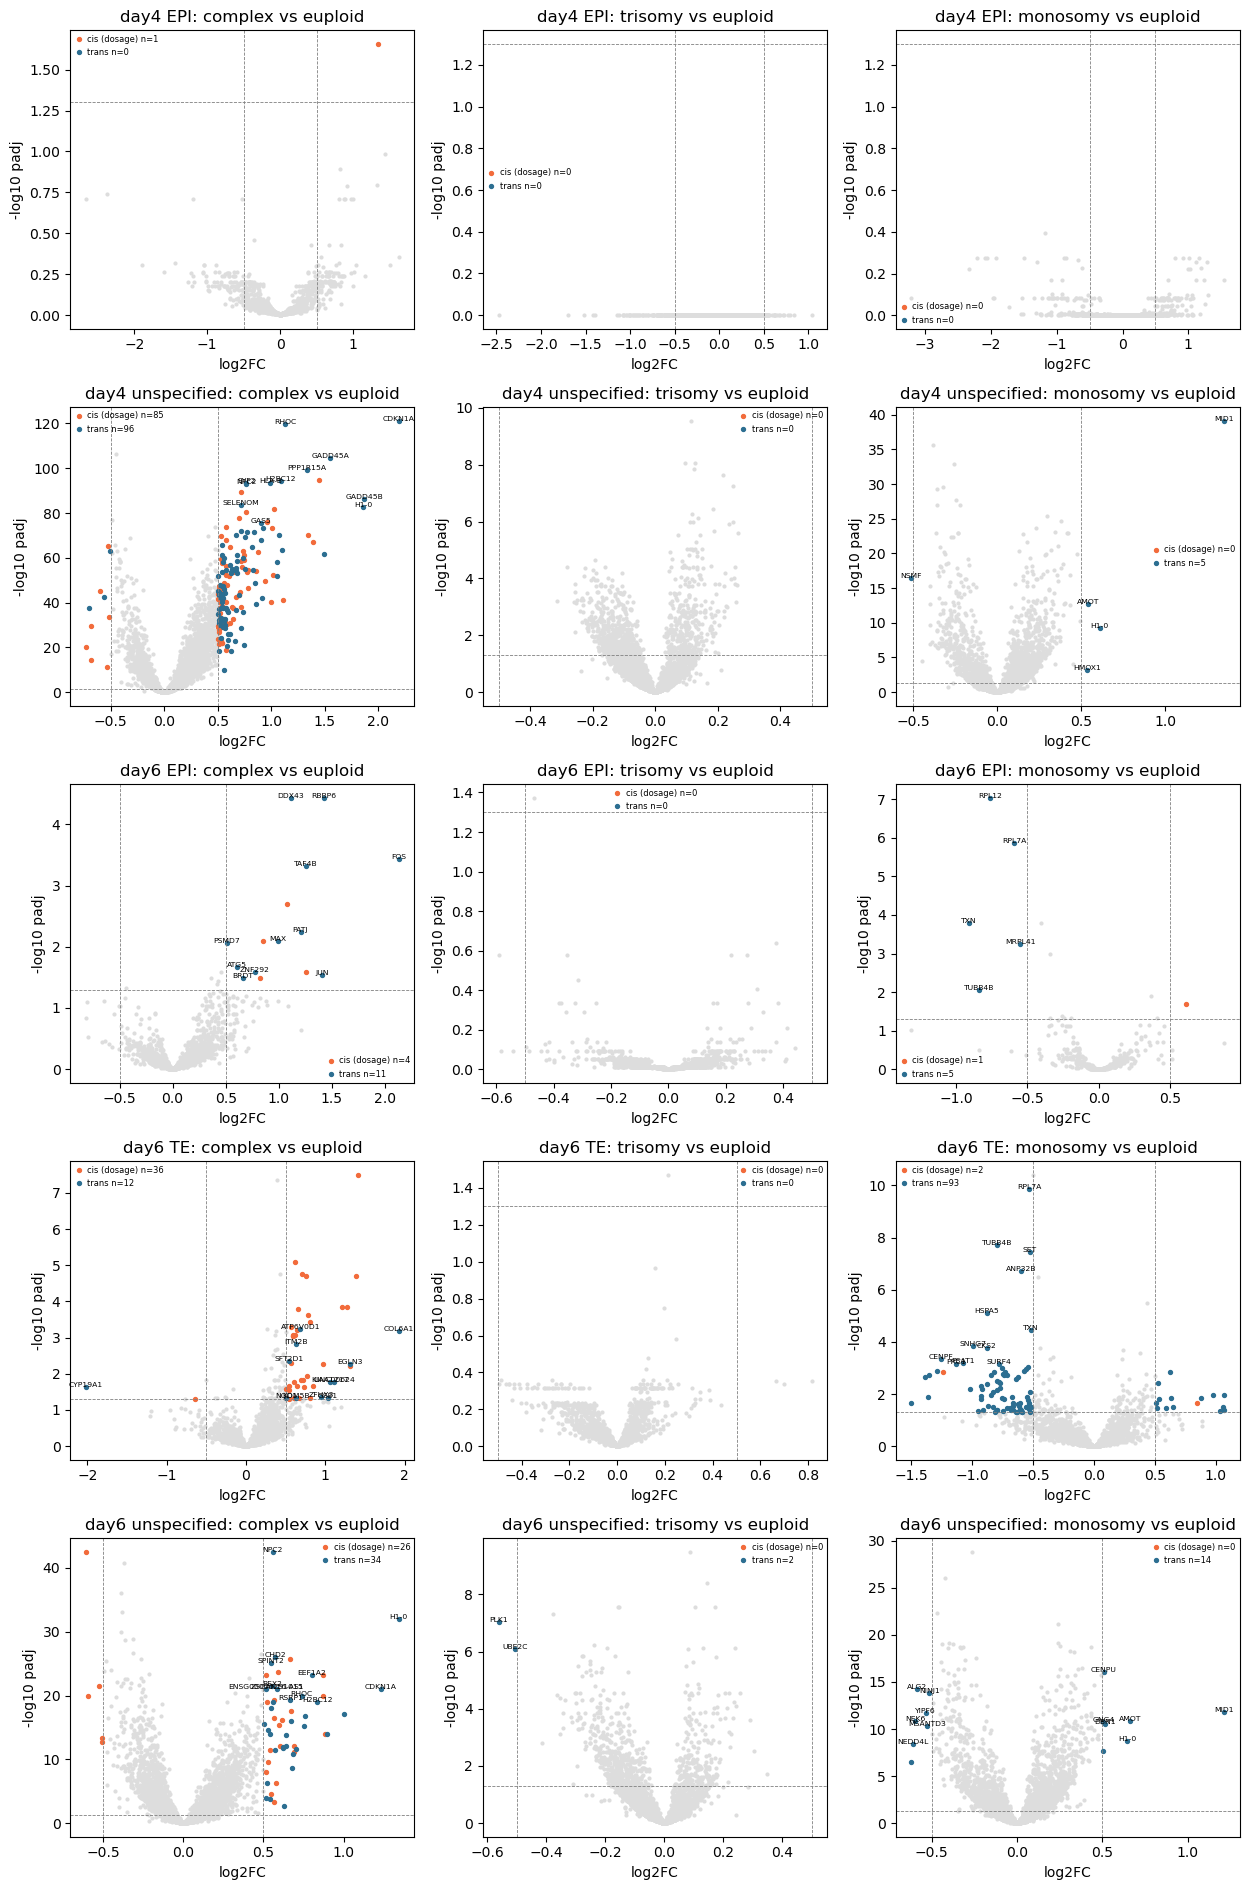

In [66]:
def volcano(res, title, ax, lfc_cut=LFC_CUT, padj_cut=PADJ_CUT, n_label=12):
    d = res.dropna(subset=["padj"]).copy()
    d["nlp"] = -np.log10(d["padj"].clip(lower=1e-300))

    ax.scatter(d.loc[~d.sig, "log2FoldChange"], d.loc[~d.sig, "nlp"],
               s=4, c="#DDDDDD", rasterized=True)
    trans_sig = d.sig & ~d.cis
    cis_sig   = d.sig & d.cis
    ax.scatter(d.loc[cis_sig, "log2FoldChange"], d.loc[cis_sig, "nlp"],
               s=8, c="#F26B3B", label=f"cis (dosage) n={cis_sig.sum()}", rasterized=True)
    ax.scatter(d.loc[trans_sig, "log2FoldChange"], d.loc[trans_sig, "nlp"],
               s=8, c="#2C6E91", label=f"trans n={trans_sig.sum()}", rasterized=True)

    for g, r in d.loc[trans_sig].nlargest(n_label, "nlp").iterrows():
        ax.text(r["log2FoldChange"], r["nlp"], g, fontsize=5.5, ha="center")

    ax.axhline(-np.log10(padj_cut), ls="--", lw=0.6, c="grey")
    for v in (-lfc_cut, lfc_cut):
        ax.axvline(v, ls="--", lw=0.6, c="grey")
    ax.set(xlabel="log2FC", ylabel="-log10 padj", title=title)
    ax.legend(fontsize=6, frameon=False)


keys = list(deg_results)
if keys:
    ncol = 3
    nrow = int(np.ceil(len(keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.8 * nrow), squeeze=False)
    for ax, k in zip(axes.ravel(), keys):
        volcano(deg_results[k], f"{k[0]} {k[1]}: {k[2]} vs euploid", ax)
    for ax in axes.ravel()[len(keys):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/volcano_cis_trans.pdf", bbox_inches="tight", dpi=300)
    plt.show()

2026-07-13 22:55:24 | [INFO] maxp pruned
2026-07-13 22:55:24 | [INFO] cmap pruned
2026-07-13 22:55:24 | [INFO] kern dropped
2026-07-13 22:55:24 | [INFO] post pruned
2026-07-13 22:55:24 | [INFO] FFTM dropped
2026-07-13 22:55:24 | [INFO] GPOS pruned
2026-07-13 22:55:24 | [INFO] GSUB pruned
2026-07-13 22:55:24 | [INFO] glyf pruned
2026-07-13 22:55:24 | [INFO] Added gid0 to subset
2026-07-13 22:55:24 | [INFO] Added first four glyphs to subset
2026-07-13 22:55:24 | [INFO] Closing glyph list over 'MATH': 65 glyphs before
2026-07-13 22:55:24 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'c', 'colon', 'd', 'e', 'eight', 'equal', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'j', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'y', 'zero']
2026-07-13 22:55:24 | [INFO] G

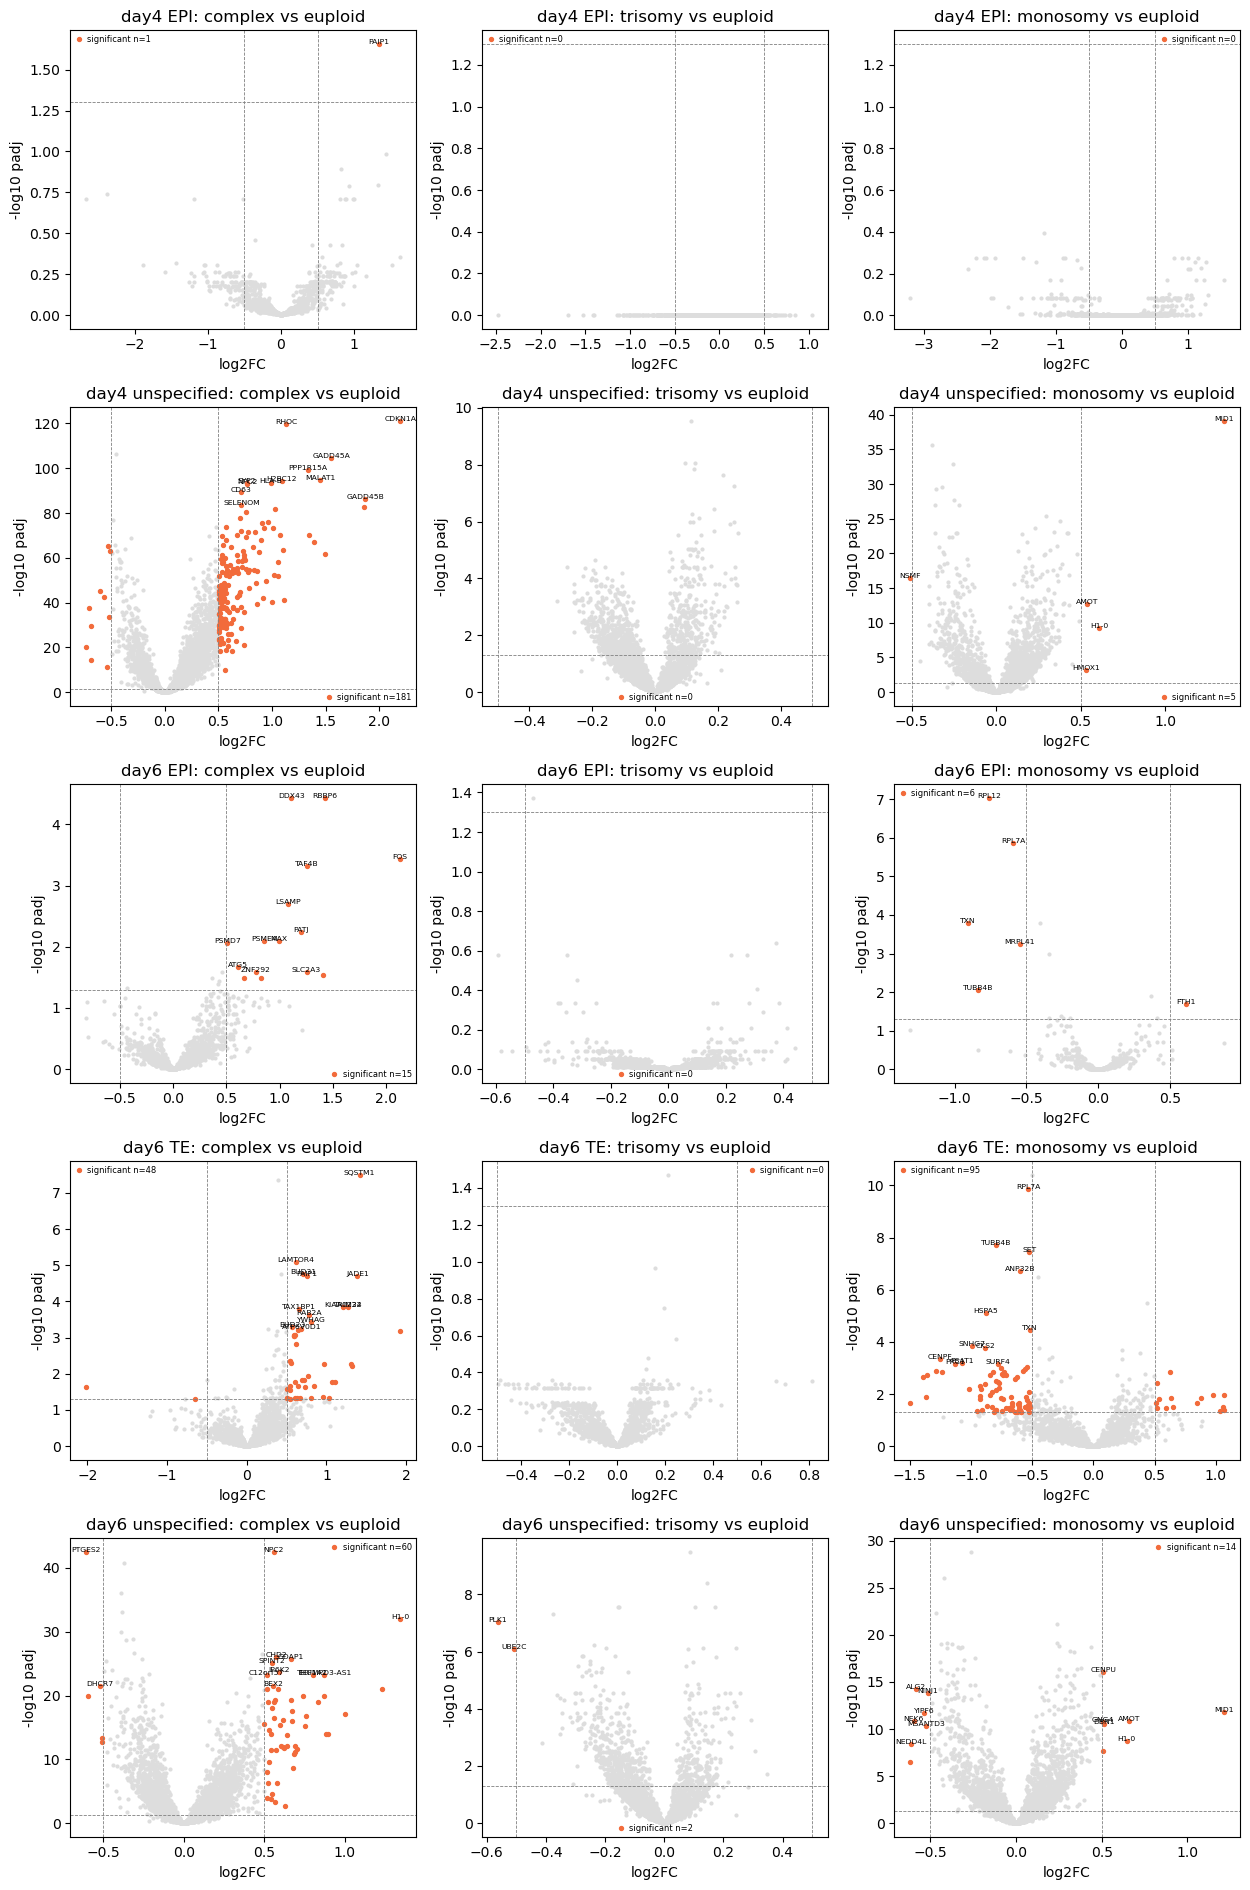

In [67]:
def volcano(res, title, ax, lfc_cut=LFC_CUT, padj_cut=PADJ_CUT, n_label=12):
    d = res.dropna(subset=["padj"]).copy()
    d["nlp"] = -np.log10(d["padj"].clip(lower=1e-300))

    ax.scatter(d.loc[~d.sig, "log2FoldChange"], d.loc[~d.sig, "nlp"],
               s=4, c="#DDDDDD", rasterized=True)
    ax.scatter(d.loc[d.sig, "log2FoldChange"], d.loc[d.sig, "nlp"],
               s=8, c="#F26B3B", label=f"significant n={int(d.sig.sum())}", rasterized=True)

    for g, r in d.loc[d.sig].nlargest(n_label, "nlp").iterrows():
        ax.text(r["log2FoldChange"], r["nlp"], g, fontsize=5.5, ha="center")

    ax.axhline(-np.log10(padj_cut), ls="--", lw=0.6, c="grey")
    for v in (-lfc_cut, lfc_cut):
        ax.axvline(v, ls="--", lw=0.6, c="grey")
    ax.set(xlabel="log2FC", ylabel="-log10 padj", title=title)
    ax.legend(fontsize=6, frameon=False)


keys = list(deg_results)
if keys:
    ncol = 3
    nrow = int(np.ceil(len(keys) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.8 * nrow), squeeze=False)
    for ax, k in zip(axes.ravel(), keys):
        volcano(deg_results[k], f"{k[0]} {k[1]}: {k[2]} vs euploid", ax)
    for ax in axes.ravel()[len(keys):]:
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/volcano.pdf", bbox_inches="tight", dpi=300)
    plt.show()

2026-07-13 22:55:38 | [INFO] maxp pruned
2026-07-13 22:55:38 | [INFO] cmap pruned
2026-07-13 22:55:38 | [INFO] kern dropped
2026-07-13 22:55:38 | [INFO] post pruned
2026-07-13 22:55:38 | [INFO] FFTM dropped
2026-07-13 22:55:38 | [INFO] GPOS pruned
2026-07-13 22:55:38 | [INFO] GSUB pruned
2026-07-13 22:55:38 | [INFO] glyf pruned
2026-07-13 22:55:38 | [INFO] Added gid0 to subset
2026-07-13 22:55:38 | [INFO] Added first four glyphs to subset
2026-07-13 22:55:38 | [INFO] Closing glyph list over 'MATH': 46 glyphs before
2026-07-13 22:55:38 | [INFO] Glyph names: ['.notdef', '.null', 'C', 'D', 'E', 'G', 'I', 'P', 'T', 'X', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'x', 'y', 'zero']
2026-07-13 22:55:38 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 38, 39, 40, 42

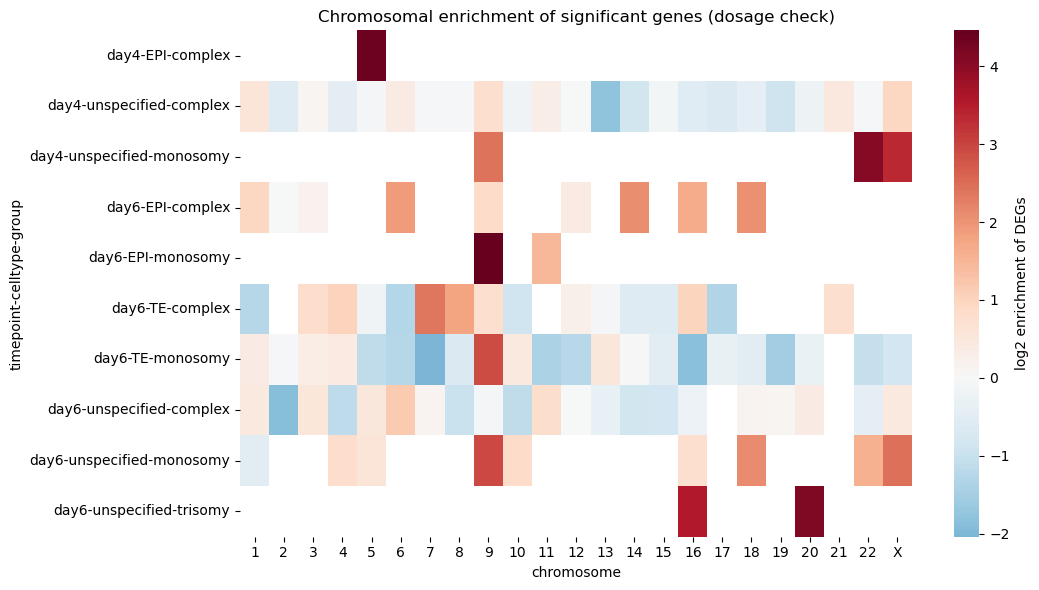

In [68]:
# Chromosome distribution of significant genes: a direct read-out of dosage.
# Trisomy/monosomy contrasts SHOULD spike on their affected chromosomes -- if they don't,
# question the ploidy calls. It doubles as a QC of xclone/scploid.
if keys:
    rows = []
    for (tp, ct, grp), res in deg_results.items():
        s = res[res.sig & res["chromosome"].notna()]
        if len(s) == 0:
            continue
        frac = s["chromosome"].value_counts(normalize=True)
        bg = adata_pb.var["chromosome"].value_counts(normalize=True)
        enr = np.log2((frac + 1e-3) / (bg.reindex(frac.index) + 1e-3))
        for chrom, v in enr.items():
            rows.append({"timepoint": tp, "celltype": ct, "group": grp,"chromosome": chrom, "log2_enrichment": v})

    chr_enr = pd.DataFrame(rows)
    order = [str(i) for i in range(1, 23)] + ["X", "Y"]
    piv = (chr_enr.pivot_table(index=["timepoint","celltype", "group"], columns="chromosome",
                               values="log2_enrichment")
                  .reindex(columns=[c for c in order if c in chr_enr["chromosome"].unique()]))

    fig, ax = plt.subplots(figsize=(11, 0.45 * len(piv) + 1.5))
    sns.heatmap(piv, cmap="RdBu_r", center=0, ax=ax,
                cbar_kws={"label": "log2 enrichment of DEGs"})
    ax.set_title("Chromosomal enrichment of significant genes (dosage check)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/DEG_chromosome_enrichment.pdf", bbox_inches="tight")
    plt.show()

## 6. GSEA on the ranked DESeq2 statistic (Hallmark)

GSEA takes **one ranked gene list per contrast** — here the Wald statistic, which already
combines effect size and precision. This is the correct input; ranking by log2FC alone lets
low-count genes with huge unstable fold-changes dominate.

Run twice per contrast: **all genes** and **trans only**.

In [69]:
# Hallmark net in decoupler's source/target format
msigdb = dc.op.resource("MSigDB")
hallmark_net = (
    msigdb[msigdb["collection"] == "hallmark"]
    .drop_duplicates(["geneset", "genesymbol"])
    .rename(columns={"geneset": "source", "genesymbol": "target"})
    [["source", "target"]]
)
# tidy names: HALLMARK_APOPTOSIS -> APOPTOSIS
hallmark_net["source"] = hallmark_net["source"].str.replace("^HALLMARK_", "", regex=True)
print(f"{hallmark_net['source'].nunique()} hallmark sets, {len(hallmark_net):,} edges")

50 hallmark sets, 11,559 edges


In [70]:
def run_gsea(res, net, trans_only=False, tmin=10):
    """GSEA on the Wald stat of one contrast. Returns tidy df."""
    d = res.dropna(subset=["stat"])
    if trans_only:
        d = d[~d["cis"]]
    mat = pd.DataFrame([d["stat"].values], index=["contrast"], columns=d.index)

    out = dc.mt.gsea(data=mat, net=net, tmin=tmin, verbose=False)
    est, pval = out[0], out[1]          # NES, p-value

    return (
        pd.DataFrame({
            "source": est.columns,
            "NES": est.loc["contrast"].values,
            "pval": pval.loc["contrast"].values,
        })
        .assign(padj=lambda x: x["pval"] * len(x))         # Bonferroni; swap for BH if preferred
        .assign(padj=lambda x: x["padj"].clip(upper=1))
        .sort_values("NES")
    )


gsea_all = []
for (tp, ct, grp), res in deg_results.items():
    for mode, tflag in [("all", False), ("trans", True)]:
        g = run_gsea(res, hallmark_net, trans_only=tflag)
        g["timepoint"], g["celltype"], g["group"], g["gene_set"] = tp, ct, grp, mode
        gsea_all.append(g)

gsea_df = pd.concat(gsea_all, ignore_index=True) if gsea_all else pd.DataFrame()
gsea_df.to_csv(f"{tab_dir}/GSEA_hallmark.csv", index=False)
gsea_df.query("gene_set == 'trans' and padj < 0.05").sort_values("NES").head(20)

Exception ignored in: <function ResourceTracker.__del__ at 0x14f81f5c4040>
Traceback (most recent call last):
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x15466e6b4040>
Traceback (most recent call last):
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/software/cellgen/team292/rs40/envs/py_decoupler/lib/python3.12/multipr

,source,NES,pval,padj,timepoint,celltype,group,gene_set
229,MYC_TARGETS_V2,-3.135753,0.0,0.0,day4,unspecified,complex,trans
230,MYC_TARGETS_V1,-2.724339,0.0,0.0,day4,unspecified,complex,trans
946,MYC_TARGETS_V1,-2.564397,0.0,0.0,day6,unspecified,complex,trans
404,MYC_TARGETS_V2,-2.515891,0.0,0.0,day4,unspecified,monosomy,trans
1032,MITOTIC_SPINDLE,-2.485524,0.0,0.0,day6,unspecified,trisomy,trans
947,MYC_TARGETS_V2,-2.449015,0.0,0.0,day6,unspecified,complex,trans
860,G2M_CHECKPOINT,-2.258019,0.0,0.0,day6,TE,monosomy,trans
231,MTORC1_SIGNALING,-2.191411,0.0,0.0,day4,unspecified,complex,trans
405,MYC_TARGETS_V1,-2.125022,0.0,0.0,day4,unspecified,monosomy,trans
313,MTORC1_SIGNALING,-2.118593,0.0,0.0,day4,unspecified,trisomy,trans


2026-07-13 22:59:26 | [INFO] maxp pruned
2026-07-13 22:59:27 | [INFO] cmap pruned
2026-07-13 22:59:27 | [INFO] kern dropped
2026-07-13 22:59:27 | [INFO] post pruned
2026-07-13 22:59:27 | [INFO] FFTM dropped
2026-07-13 22:59:27 | [INFO] GPOS pruned
2026-07-13 22:59:27 | [INFO] GSUB pruned
2026-07-13 22:59:27 | [INFO] glyf pruned
2026-07-13 22:59:27 | [INFO] Added gid0 to subset
2026-07-13 22:59:27 | [INFO] Added first four glyphs to subset
2026-07-13 22:59:27 | [INFO] Closing glyph list over 'MATH': 59 glyphs before
2026-07-13 22:59:27 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'a', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'x', 'y', 'zero']
2026-07-13 22:59:27 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11,

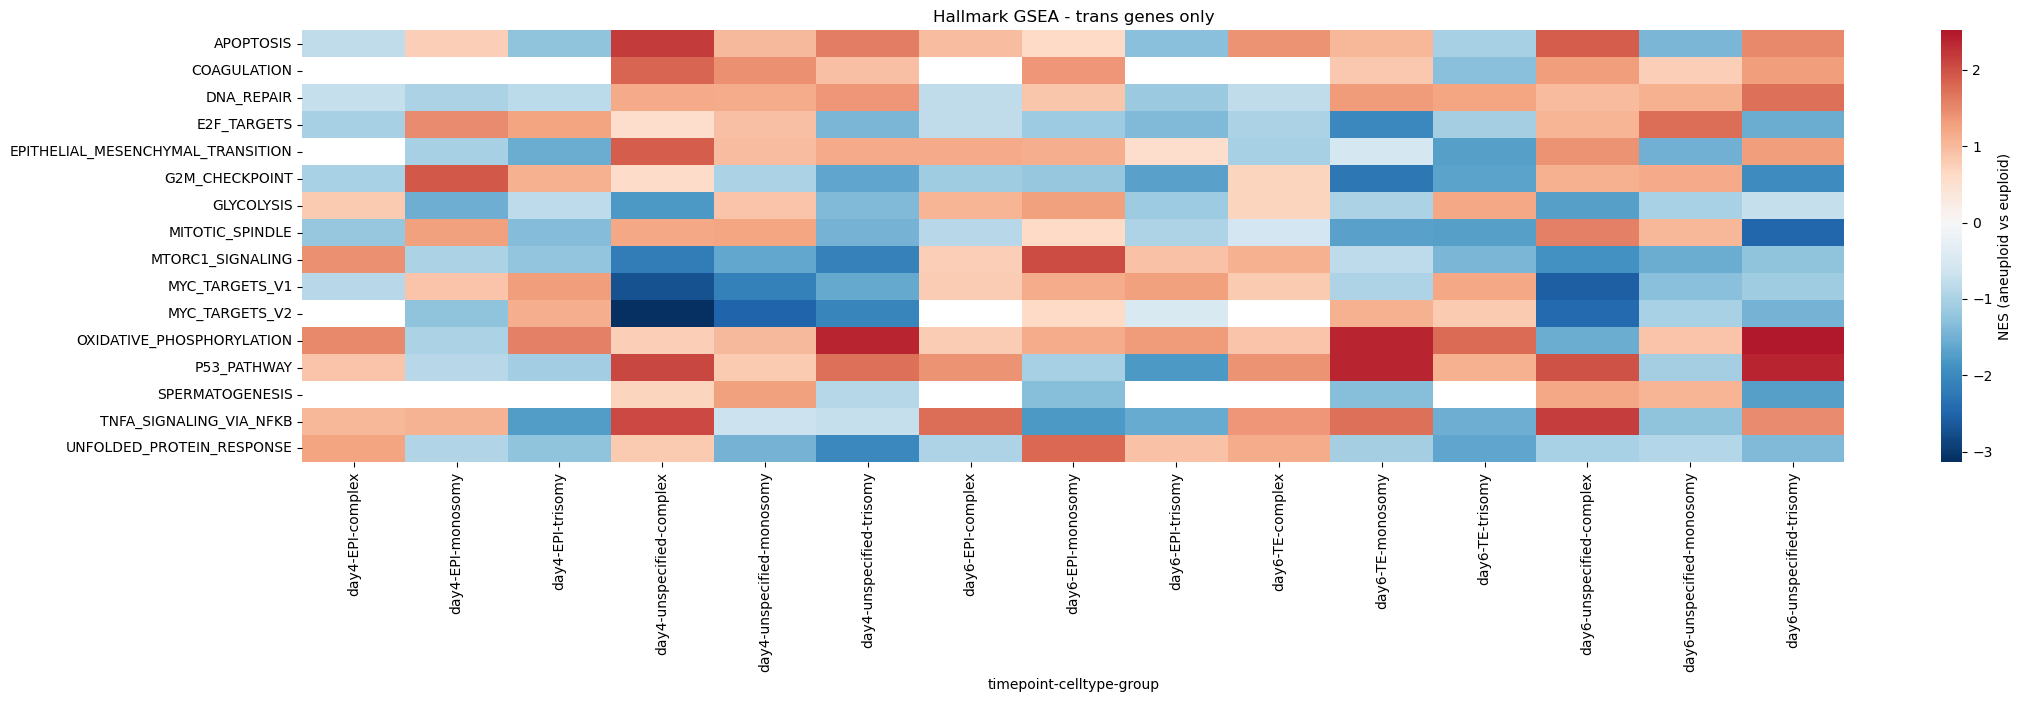

In [71]:
# Hallmark NES heatmap -- TRANS ONLY (the biology).  * marks padj < 0.05
sub = gsea_df.query("gene_set == 'trans'")

if len(sub):
    piv = sub.pivot_table(index="source", columns=["timepoint", "celltype", "group"], values="NES")
    star = sub.pivot_table(index="source", columns=["celltype", "group"], values="padj")
    star = star.reindex_like(piv).map(lambda p: "*" if pd.notna(p) and p < 0.05 else "")

    # show sets significant somewhere
    keep_rows = (sub.groupby("source")["padj"].min() < 0.05)
    keep_rows = keep_rows[keep_rows].index
    piv, star = piv.loc[piv.index.isin(keep_rows)], star.loc[star.index.isin(keep_rows)]

    fig, ax = plt.subplots(figsize=(1.3 * piv.shape[1] + 3, 0.32 * len(piv) + 2))
    sns.heatmap(piv, cmap="RdBu_r", center=0, annot=star, fmt="", ax=ax,
                annot_kws={"color": "black", "fontsize": 9},
                cbar_kws={"label": "NES (aneuploid vs euploid)"})
    ax.set_title("Hallmark GSEA - trans genes only")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/GSEA_hallmark_trans_heatmap.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No GSEA results -- no contrasts succeeded.")

2026-07-13 22:59:33 | [INFO] maxp pruned
2026-07-13 22:59:33 | [INFO] cmap pruned
2026-07-13 22:59:33 | [INFO] kern dropped
2026-07-13 22:59:33 | [INFO] post pruned
2026-07-13 22:59:33 | [INFO] FFTM dropped
2026-07-13 22:59:33 | [INFO] GPOS pruned
2026-07-13 22:59:33 | [INFO] GSUB pruned
2026-07-13 22:59:33 | [INFO] glyf pruned
2026-07-13 22:59:33 | [INFO] Added gid0 to subset
2026-07-13 22:59:33 | [INFO] Added first four glyphs to subset
2026-07-13 22:59:33 | [INFO] Closing glyph list over 'MATH': 59 glyphs before
2026-07-13 22:59:33 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'a', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'v', 'x', 'y', 'zero']
2026-07-13 22:59:33 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11,

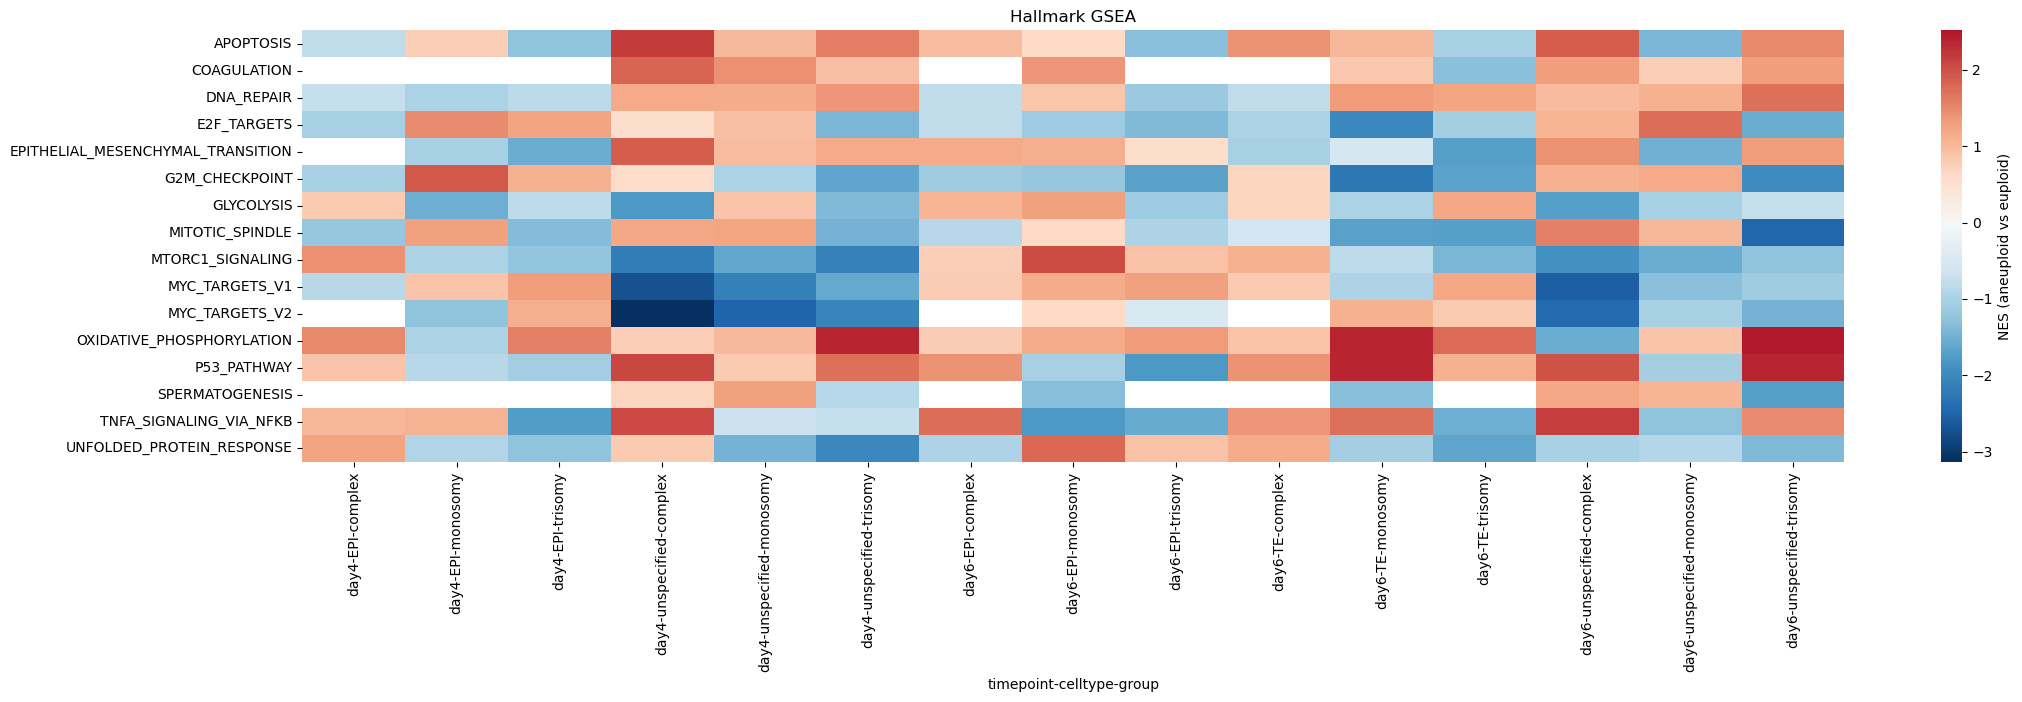

In [72]:
# Hallmark NES heatmap -- TRANS ONLY (the biology).  * marks padj < 0.0

if len(gsea_df):
    piv = sub.pivot_table(index="source", columns=["timepoint", "celltype", "group"], values="NES")
    star = sub.pivot_table(index="source", columns=["celltype", "group"], values="padj")
    star = star.reindex_like(piv).map(lambda p: "*" if pd.notna(p) and p < 0.05 else "")

    # show sets significant somewhere
    keep_rows = (sub.groupby("source")["padj"].min() < 0.05)
    keep_rows = keep_rows[keep_rows].index
    piv, star = piv.loc[piv.index.isin(keep_rows)], star.loc[star.index.isin(keep_rows)]

    fig, ax = plt.subplots(figsize=(1.3 * piv.shape[1] + 3, 0.32 * len(piv) + 2))
    sns.heatmap(piv, cmap="RdBu_r", center=0, annot=star, fmt="", ax=ax,
                annot_kws={"color": "black", "fontsize": 9},
                cbar_kws={"label": "NES (aneuploid vs euploid)"})
    ax.set_title("Hallmark GSEA")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/GSEA_hallmark_all_heatmap.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No GSEA results -- no contrasts succeeded.")

2026-07-13 22:59:37 | [INFO] maxp pruned
2026-07-13 22:59:37 | [INFO] cmap pruned
2026-07-13 22:59:37 | [INFO] kern dropped
2026-07-13 22:59:37 | [INFO] post pruned
2026-07-13 22:59:37 | [INFO] FFTM dropped
2026-07-13 22:59:37 | [INFO] GPOS pruned
2026-07-13 22:59:37 | [INFO] GSUB pruned
2026-07-13 22:59:37 | [INFO] glyf pruned
2026-07-13 22:59:37 | [INFO] Added gid0 to subset
2026-07-13 22:59:37 | [INFO] Added first four glyphs to subset
2026-07-13 22:59:37 | [INFO] Closing glyph list over 'MATH': 32 glyphs before
2026-07-13 22:59:37 | [INFO] Glyph names: ['.notdef', '.null', 'E', 'N', 'P', 'S', 'a', 'd', 'e', 'equal', 'f', 'g', 'h', 'hyphen', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'parenleft', 'parenright', 'r', 's', 'space', 't', 'three', 'two', 'v', 'y', 'zero']
2026-07-13 22:59:37 | [INFO] Glyph IDs:   [0, 1, 2, 3, 11, 12, 16, 19, 20, 21, 22, 32, 40, 49, 51, 54, 68, 71, 72, 73, 74, 75, 76, 79, 81, 82, 85, 86, 87, 89, 92, 3228]
2026-07-13 22:59:37 | [INFO] Closed g

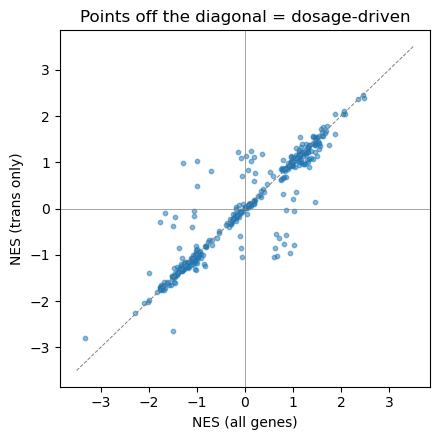

In [73]:
# Side-by-side: does a pathway survive the cis->trans filter?
# Sets that collapse from 'all' to 'trans' were dosage artifacts.
if len(gsea_df):
    cmp = gsea_df.pivot_table(index=["celltype", "group", "source"],
                              columns="gene_set", values="NES").reset_index().dropna()
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.scatter(cmp["all"], cmp["trans"], s=10, alpha=0.5)
    lim = np.nanmax(np.abs(cmp[["all", "trans"]].values)) * 1.05
    ax.plot([-lim, lim], [-lim, lim], ls="--", lw=0.7, c="grey")
    ax.axhline(0, lw=0.5, c="grey"); ax.axvline(0, lw=0.5, c="grey")
    ax.set(xlabel="NES (all genes)", ylabel="NES (trans only)",
           title="Points off the diagonal = dosage-driven")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/GSEA_cis_vs_trans_NES.pdf", bbox_inches="tight")
    plt.show()

## 7. PROGENy pathway activity + CollecTRI TF activity (ULM on contrast statistics)

Footprint methods: infer activity from the *targets* of a pathway/TF rather than from the
pathway members' own transcripts. Input = the Wald-statistic matrix (contrasts × genes).

ULM (univariate) is used here — see the note at the top of the notebook.

In [74]:
progeny  = dc.op.progeny(organism="human", top=500)
collectri = dc.op.collectri(organism="human")
print("PROGENy pathways:", progeny["source"].nunique(),
      "| CollecTRI TFs:", collectri["source"].nunique())

PROGENy pathways: 14 | CollecTRI TFs: 1185


(15, 5771)


2026-07-13 23:00:04 | [INFO] maxp pruned
2026-07-13 23:00:04 | [INFO] cmap pruned
2026-07-13 23:00:04 | [INFO] kern dropped
2026-07-13 23:00:04 | [INFO] post pruned
2026-07-13 23:00:04 | [INFO] FFTM dropped
2026-07-13 23:00:04 | [INFO] GPOS pruned
2026-07-13 23:00:04 | [INFO] GSUB pruned
2026-07-13 23:00:04 | [INFO] glyf pruned
2026-07-13 23:00:04 | [INFO] Added gid0 to subset
2026-07-13 23:00:04 | [INFO] Added first four glyphs to subset
2026-07-13 23:00:04 | [INFO] Closing glyph list over 'MATH': 60 glyphs before
2026-07-13 23:00:04 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'a', 'asterisk', 'b', 'bar', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'hyphen', 'i', 'k', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'p', 'parenleft', 'parenright', 'r', 's', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'w', 'x', 'y', 'zero']
2026-07-13 23:00:04 | [INFO] Glyph IDs:   [0, 1, 2,

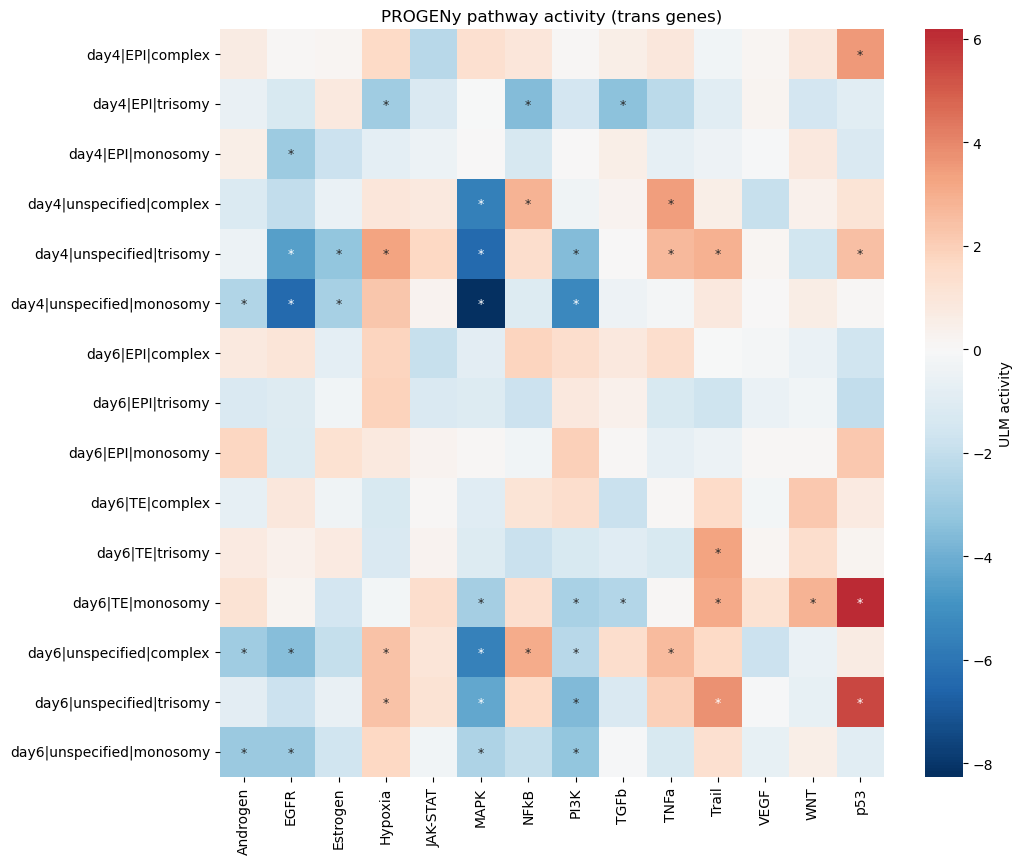

In [75]:
def contrast_stat_matrix(deg_results, trans_only=True):
    rows = {}
    for (tp, ct, grp), res in deg_results.items():
        d = res.dropna(subset=["stat"])
        if trans_only:
            d = d[~d["cis"]]
        rows[f"{tp}|{ct}|{grp}"] = d["stat"]
    return pd.DataFrame(rows).T.fillna(0) # contrasts x genes


stat_mat = contrast_stat_matrix(deg_results, trans_only=True)
print(stat_mat.shape)

# PROGENy
prog_est, prog_p = dc.mt.ulm(data=stat_mat, net=progeny, tmin=5, verbose=False)

fig, ax = plt.subplots(figsize=(0.55 * prog_est.shape[1] + 3, 0.45 * len(prog_est) + 2))
star = prog_p.map(lambda p: "*" if p < 0.05 else "")
sns.heatmap(prog_est, cmap="RdBu_r", center=0, annot=star, fmt="",
            annot_kws={"fontsize": 9}, ax=ax, cbar_kws={"label": "ULM activity"})
ax.set_title("PROGENy pathway activity (trans genes)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/PROGENy_ulm_contrasts.pdf", bbox_inches="tight")
plt.show()

prog_est.T.join(prog_p.T, lsuffix="_score", rsuffix="_pval").to_csv(
    f"{tab_dir}/PROGENy_ulm_contrasts.csv")

2026-07-13 23:00:11 | [INFO] maxp pruned
2026-07-13 23:00:11 | [INFO] cmap pruned
2026-07-13 23:00:11 | [INFO] kern dropped
2026-07-13 23:00:11 | [INFO] post pruned
2026-07-13 23:00:11 | [INFO] FFTM dropped
2026-07-13 23:00:11 | [INFO] GPOS pruned
2026-07-13 23:00:11 | [INFO] GSUB pruned
2026-07-13 23:00:11 | [INFO] glyf pruned
2026-07-13 23:00:11 | [INFO] Added gid0 to subset
2026-07-13 23:00:11 | [INFO] Added first four glyphs to subset
2026-07-13 23:00:11 | [INFO] Closing glyph list over 'MATH': 61 glyphs before
2026-07-13 23:00:11 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Z', 'a', 'asterisk', 'bar', 'c', 'd', 'e', 'f', 'five', 'four', 'g', 'hyphen', 'i', 'l', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'y', 'zero']
2026-07-13 23:00:11 | [INFO] Glyph IDs:  

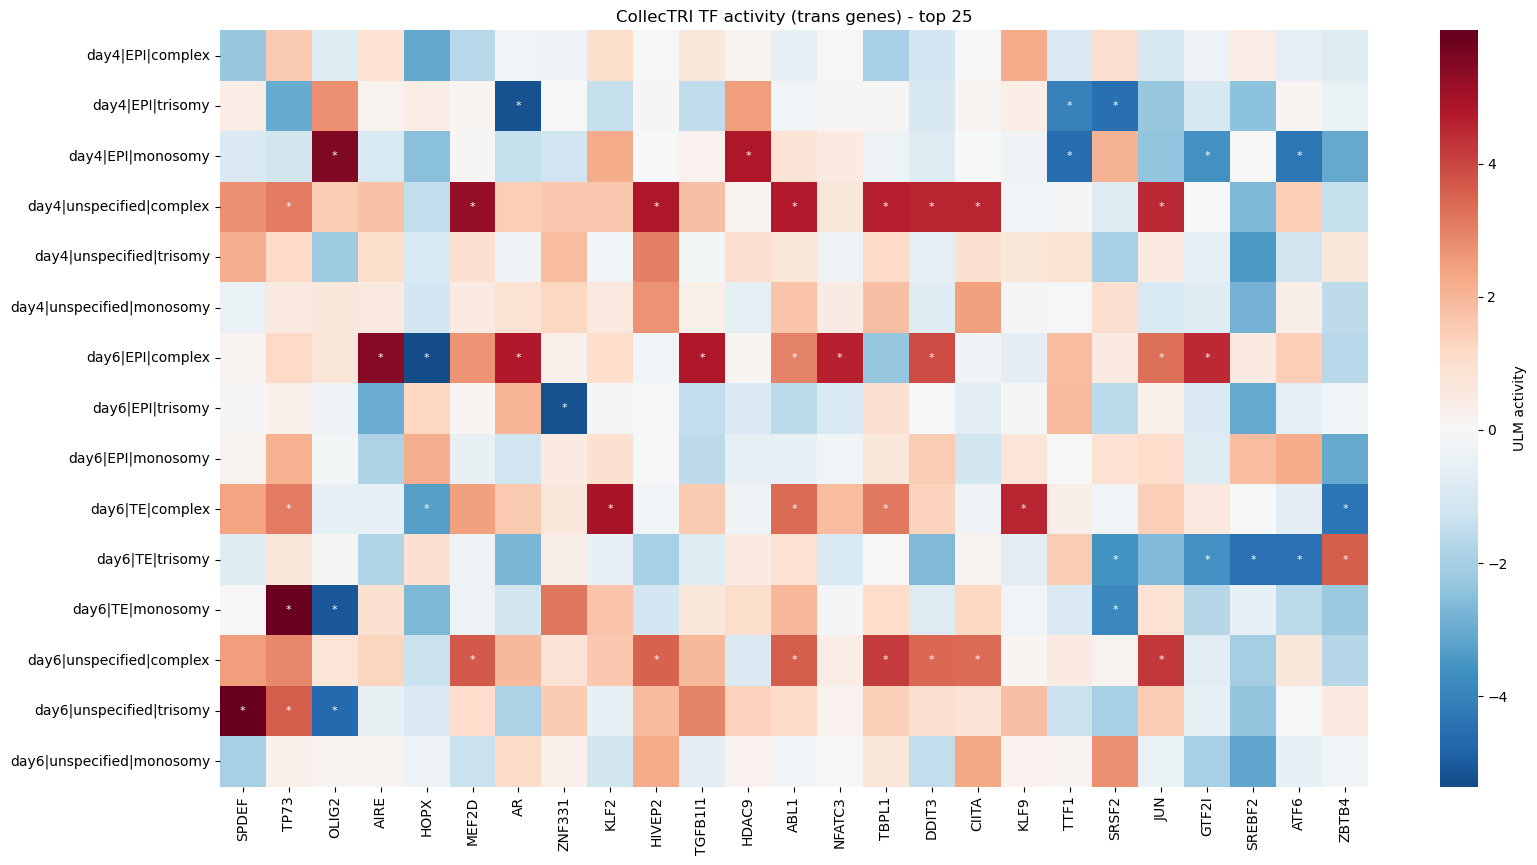

                           TP53_activity      pval
day4|EPI|complex                0.181761  0.999224
day4|EPI|trisomy               -1.816612  0.485299
day4|EPI|monosomy              -0.843885  0.845466
day4|unspecified|complex        0.548255  0.803700
day4|unspecified|trisomy        0.011234  0.997059
day4|unspecified|monosomy      -0.471418  0.999760
day6|EPI|complex                1.472798  0.477921
day6|EPI|trisomy                0.757613  0.834948
day6|EPI|monosomy               0.786382  0.809916
day6|TE|complex                 3.536015  0.013888
day6|TE|trisomy                -1.562787  0.482961
day6|TE|monosomy                3.391703  0.051396
day6|unspecified|complex       -0.259249  0.932964
day6|unspecified|trisomy        0.711894  0.753196
day6|unspecified|monosomy      -0.879288  0.918768


In [76]:
# CollecTRI TF activity -- top variable TFs across contrasts
tf_est, tf_p = dc.mt.ulm(data=stat_mat, net=collectri, tmin=5, verbose=False)
tf_est.T.join(tf_p.T, lsuffix="_score", rsuffix="_pval").to_csv(
    f"{tab_dir}/CollecTRI_ulm_contrasts.csv")

top_tfs = tf_est.abs().max(axis=0).sort_values(ascending=False).head(25).index
sub_est, sub_p = tf_est[top_tfs], tf_p[top_tfs]

fig, ax = plt.subplots(figsize=(0.55 * len(top_tfs) + 3, 0.45 * len(sub_est) + 2))
sns.heatmap(sub_est, cmap="RdBu_r", center=0,
            annot=sub_p.map(lambda p: "*" if p < 0.05 else ""), fmt="",
            annot_kws={"fontsize": 8}, ax=ax, cbar_kws={"label": "ULM activity"})
ax.set_title("CollecTRI TF activity (trans genes) - top 25")
plt.tight_layout()
plt.savefig(f"{fig_dir}/CollecTRI_ulm_contrasts.pdf", bbox_inches="tight")
plt.show()

# TP53 specifically -- the a priori hypothesis for aneuploidy-triggered elimination
if "TP53" in tf_est.columns:
    print(pd.DataFrame({"TP53_activity": tf_est["TP53"], "pval": tf_p["TP53"]}))

## 8. Per-sample MLM scores (PROGENy / Hallmark) → plots with honest statistics

Section 7 gives one activity value per *contrast*. For **plots** and **per-embryo statistics**
you want one score per pseudobulk sample. MLM is appropriate here (many samples).

The statistics use a **paired test across embryos** where possible — this is the correct
test at the level of the biological replicate, and it is the number you can defend.

In [77]:
# logCPM pseudobulk for scoring
pb_norm = pdata.copy()
dc.pp.filter_by_expr(pb_norm, group="pb_group", min_count=10, min_total_count=15)
sc.pp.normalize_total(pb_norm, target_sum=1e6)
sc.pp.log1p(pb_norm)

dc.mt.mlm(data=pb_norm, net=progeny, tmin=5, verbose=False)
prog_scores = dc.pp.get_obsm(adata=pb_norm, key="score_mlm")

dc.mt.mlm(data=pb_norm, net=hallmark_net, tmin=10, verbose=False)
hall_scores = dc.pp.get_obsm(adata=pb_norm, key="score_mlm")

prog_scores.to_df().join(pb_norm.obs[["embryo", "celltype", "ploidy"]]).to_csv(
    f"{tab_dir}/PROGENy_mlm_pseudobulk.csv")
hall_scores.to_df().join(pb_norm.obs[["embryo", "celltype", "ploidy"]]).to_csv(
    f"{tab_dir}/Hallmark_mlm_pseudobulk.csv")

print(prog_scores.shape, hall_scores.shape)

(2439, 14) (2439, 50)


In [78]:
from scipy.stats import wilcoxon, mannwhitneyu

def paired_test(scores_ad, pathway, celltype, group, reference=REFERENCE):
    """Paired Wilcoxon across embryos where both ploidy classes exist;
    falls back to unpaired Mann-Whitney otherwise. Returns (p, n, paired?)."""
    df = scores_ad.to_df()[[pathway]].join(scores_ad.obs[["embryo", "celltype", "ploidy"]])
    df = df[(df["celltype"] == celltype) & (df["ploidy"].isin([reference, group]))]

    wide = df.pivot_table(index="embryo", columns="ploidy", values=pathway, observed=True)
    both = wide.dropna(subset=[reference, group]) if group in wide.columns else pd.DataFrame()

    if len(both) >= 5:                       # paired across embryos
        p = wilcoxon(both[group], both[reference]).pvalue
        return p, len(both), True
    a = df.loc[df["ploidy"] == group, pathway]
    b = df.loc[df["ploidy"] == reference, pathway]
    if len(a) >= 3 and len(b) >= 3:
        return mannwhitneyu(a, b, alternative="two-sided").pvalue, min(len(a), len(b)), False
    return np.nan, 0, False


# Focused test: the a priori elimination pathways
focus = [p for p in ["APOPTOSIS", "P53_PATHWAY", "DNA_REPAIR", "TNFA_SIGNALING_VIA_NFKB",
                     "UNFOLDED_PROTEIN_RESPONSE", "MYC_TARGETS_V1", "G2M_CHECKPOINT"]
         if p in hall_scores.var_names]

rows = []
for ct in celltypes:
    for grp in TEST_GROUPS:
        for pw in focus:
            p, n, paired = paired_test(hall_scores, pw, ct, grp)
            rows.append({"celltype": ct, "group": grp, "pathway": pw,
                         "pval": p, "n": n, "paired": paired})

stats_df = pd.DataFrame(rows).dropna(subset=["pval"])
# BH across the whole family of tests
from statsmodels.stats.multitest import multipletests
stats_df["padj"] = multipletests(stats_df["pval"], method="fdr_bh")[1]
stats_df.to_csv(f"{tab_dir}/hallmark_focus_tests.csv", index=False)
stats_df.sort_values("padj").head(15)

,celltype,group,pathway,pval,n,paired,padj
47,unspecified,complex,MYC_TARGETS_V1,7.508891e-80,495,True,4.730601e-78
54,unspecified,trisomy,MYC_TARGETS_V1,7.683885e-67,413,True,2.420424e-65
46,unspecified,complex,UNFOLDED_PROTEIN_RESPONSE,6.520489e-66,495,True,1.369303e-64
61,unspecified,monosomy,MYC_TARGETS_V1,4.332741e-62,382,True,6.824066e-61
53,unspecified,trisomy,UNFOLDED_PROTEIN_RESPONSE,2.047081e-59,413,True,2.579322e-58
45,unspecified,complex,TNFA_SIGNALING_VIA_NFKB,1.336194e-55,495,True,1.403004e-54
55,unspecified,trisomy,G2M_CHECKPOINT,3.436873e-54,413,True,3.093186e-53
60,unspecified,monosomy,UNFOLDED_PROTEIN_RESPONSE,4.367561e-54,382,True,3.439454e-53
51,unspecified,trisomy,DNA_REPAIR,4.007600e-53,413,True,2.805320e-52
44,unspecified,complex,DNA_REPAIR,2.274923e-49,495,True,1.433202e-48


2026-07-13 23:00:52 | [INFO] maxp pruned
2026-07-13 23:00:52 | [INFO] cmap pruned
2026-07-13 23:00:52 | [INFO] kern dropped
2026-07-13 23:00:52 | [INFO] post pruned
2026-07-13 23:00:52 | [INFO] FFTM dropped
2026-07-13 23:00:52 | [INFO] GPOS pruned
2026-07-13 23:00:52 | [INFO] GSUB pruned
2026-07-13 23:00:52 | [INFO] glyf pruned
2026-07-13 23:00:52 | [INFO] Added gid0 to subset
2026-07-13 23:00:52 | [INFO] Added first four glyphs to subset
2026-07-13 23:00:52 | [INFO] Closing glyph list over 'MATH': 52 glyphs before
2026-07-13 23:00:52 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'bar', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'y', 'zero']
2026-07-13 23:00:52 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 36, 3

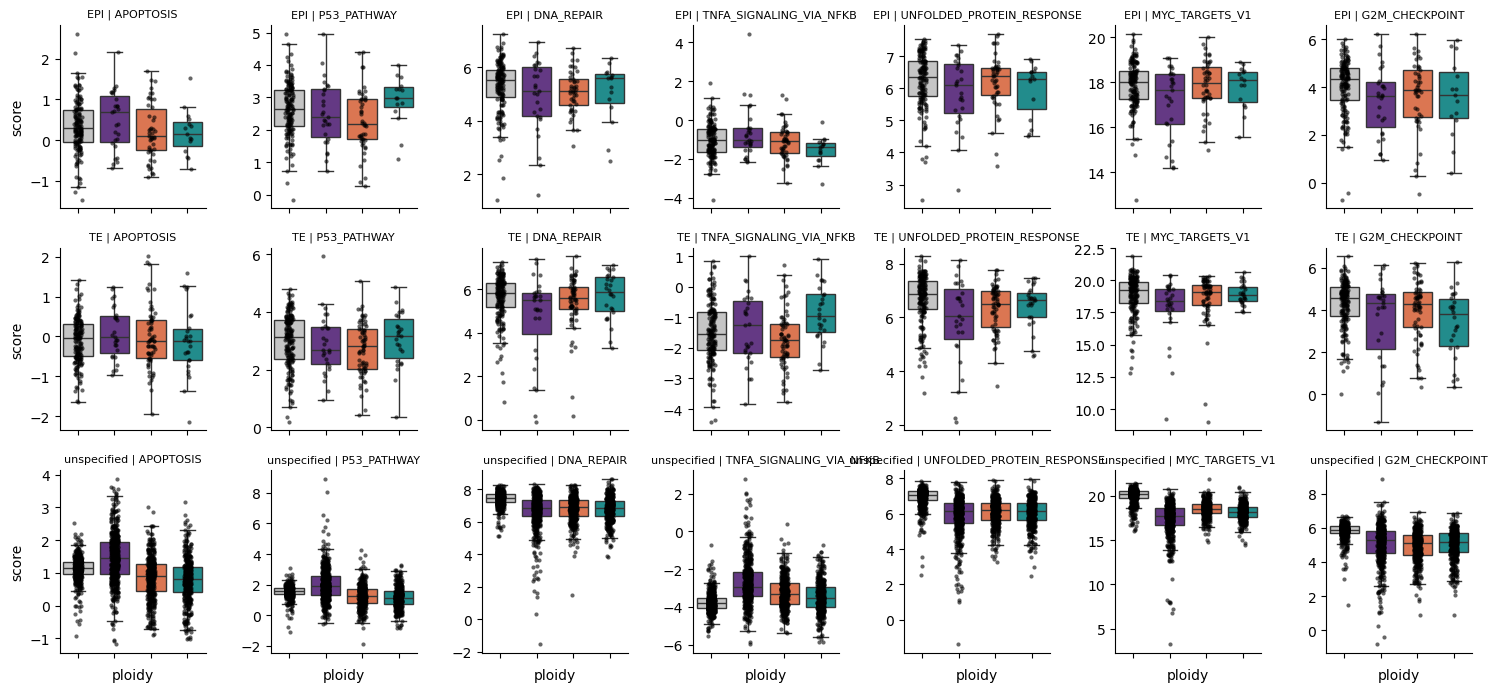

In [79]:
# Boxplots per embryo -- each point is ONE EMBRYO, which is the honest unit.
df = hall_scores.to_df()[focus].join(hall_scores.obs[["embryo", "timepoint", "celltype", "ploidy"]])
long = df.melt(id_vars=["embryo", "timepoint", "celltype", "ploidy"],
               var_name="pathway", value_name="score")

g = sns.catplot(data=long, x="ploidy", y="score", col="pathway", row="celltype",
                kind="box", palette=palette, height=2.4, aspect=0.9,
                order=["euploid"] + TEST_GROUPS, fliersize=0, sharey=False)
g.map_dataframe(sns.stripplot, x="ploidy", y="score",
                order=["euploid"] + TEST_GROUPS, color="black", size=3, alpha=0.6)
g.set_titles("{row_name} | {col_name}", size=8)
g.set_xticklabels(rotation=45, ha="right")
g.savefig(f"{fig_dir}/hallmark_mlm_boxplots.pdf", bbox_inches="tight")
plt.show()

2026-07-13 23:01:43 | [INFO] maxp pruned
2026-07-13 23:01:43 | [INFO] cmap pruned
2026-07-13 23:01:43 | [INFO] kern dropped
2026-07-13 23:01:43 | [INFO] post pruned
2026-07-13 23:01:43 | [INFO] FFTM dropped
2026-07-13 23:01:43 | [INFO] GPOS pruned
2026-07-13 23:01:43 | [INFO] GSUB pruned
2026-07-13 23:01:44 | [INFO] glyf pruned
2026-07-13 23:01:44 | [INFO] Added gid0 to subset
2026-07-13 23:01:44 | [INFO] Added first four glyphs to subset
2026-07-13 23:01:44 | [INFO] Closing glyph list over 'MATH': 56 glyphs before
2026-07-13 23:01:44 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'a', 'bar', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'underscore', 'x', 'y', 'zero']
2026-07-13 23:01:44 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 2

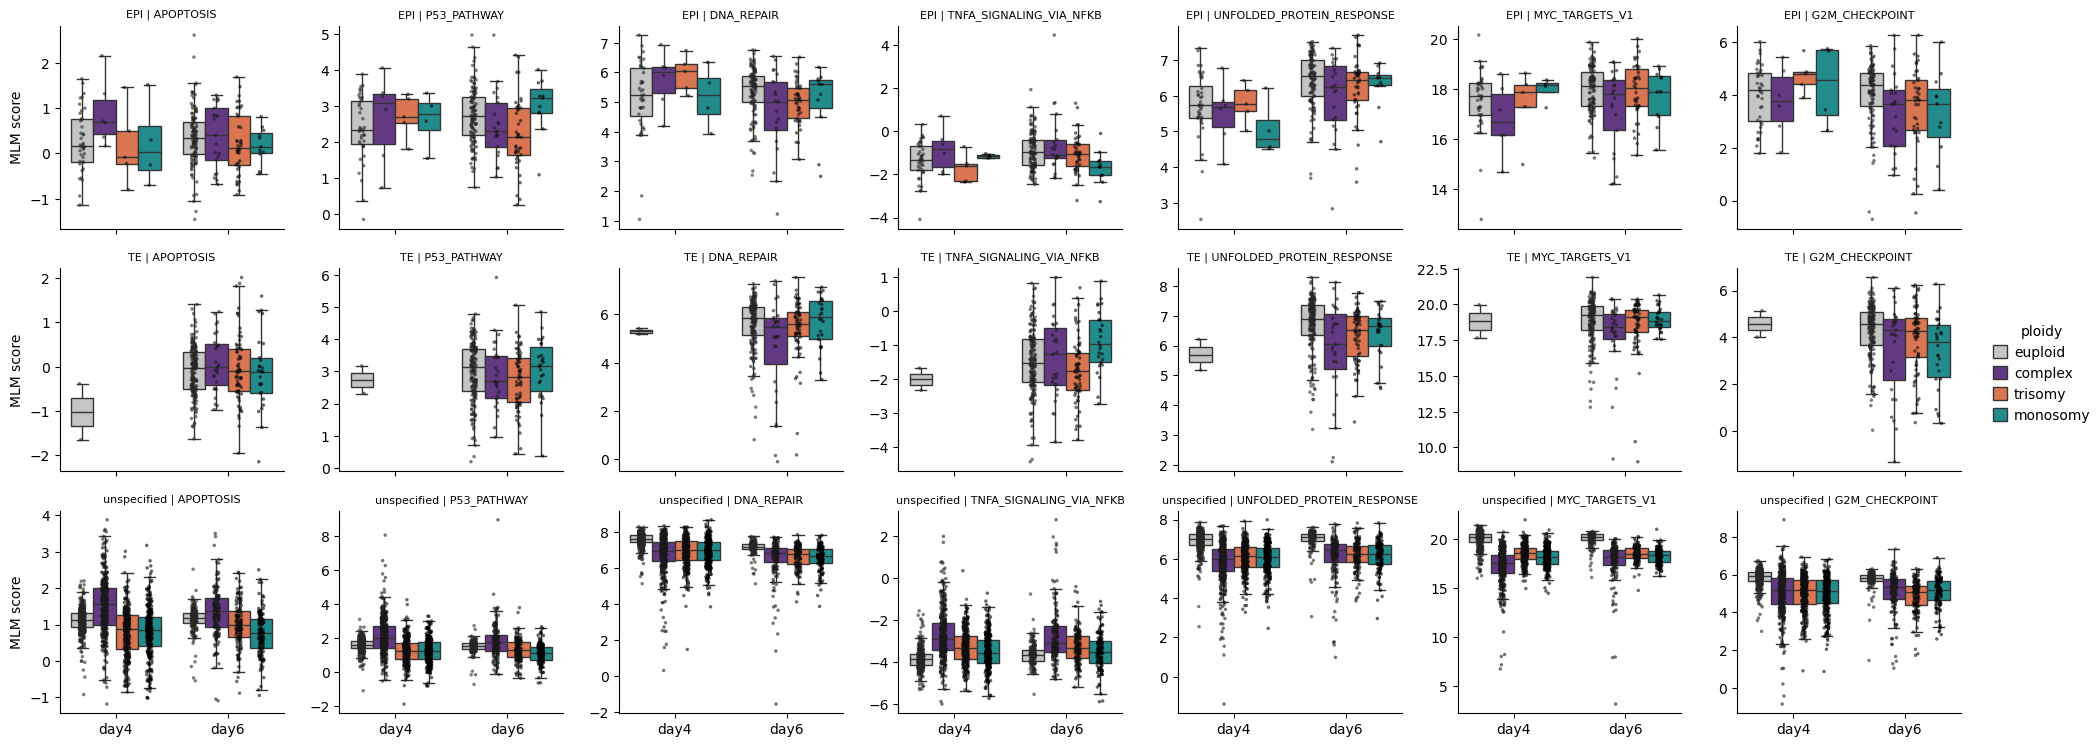

In [80]:
df = hall_scores.to_df()[focus].join(
    hall_scores.obs[["embryo", "timepoint", "celltype", "ploidy"]])
long = df.melt(id_vars=["embryo", "timepoint", "celltype", "ploidy"],
               var_name="pathway", value_name="score")

tp_order = [t for t in ["day4", "day6"] if t in long["timepoint"].unique()]
pl_order = ["euploid"] + TEST_GROUPS

g = sns.catplot(
    data=long, x="timepoint", y="score", hue="ploidy",
    col="pathway", row="celltype",
    kind="box", palette=palette, height=2.6, aspect=1.1,
    order=tp_order, hue_order=pl_order, fliersize=0, sharey=False,
    legend_out=True,
)
# dodge=True is essential -- without it the strip points all land on the box centre
g.map_dataframe(sns.stripplot, x="timepoint", y="score", hue="ploidy",
                order=tp_order, hue_order=pl_order,
                dodge=True, color="black", size=2.5, alpha=0.6, legend=False)

g.set_titles("{row_name} | {col_name}", size=8)
g.set_axis_labels("", "MLM score")
g.savefig(f"{fig_dir}/hallmark_mlm_boxplots_by_timepoint.pdf", bbox_inches="tight")
plt.show()

2026-07-13 23:02:21 | [INFO] maxp pruned
2026-07-13 23:02:21 | [INFO] cmap pruned
2026-07-13 23:02:21 | [INFO] kern dropped
2026-07-13 23:02:21 | [INFO] post pruned
2026-07-13 23:02:21 | [INFO] FFTM dropped
2026-07-13 23:02:21 | [INFO] GPOS pruned
2026-07-13 23:02:21 | [INFO] GSUB pruned
2026-07-13 23:02:21 | [INFO] glyf pruned
2026-07-13 23:02:21 | [INFO] Added gid0 to subset
2026-07-13 23:02:21 | [INFO] Added first four glyphs to subset
2026-07-13 23:02:21 | [INFO] Closing glyph list over 'MATH': 54 glyphs before
2026-07-13 23:02:21 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'a', 'bar', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'l', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'y', 'zero']
2026-07-13 23:02:21 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 

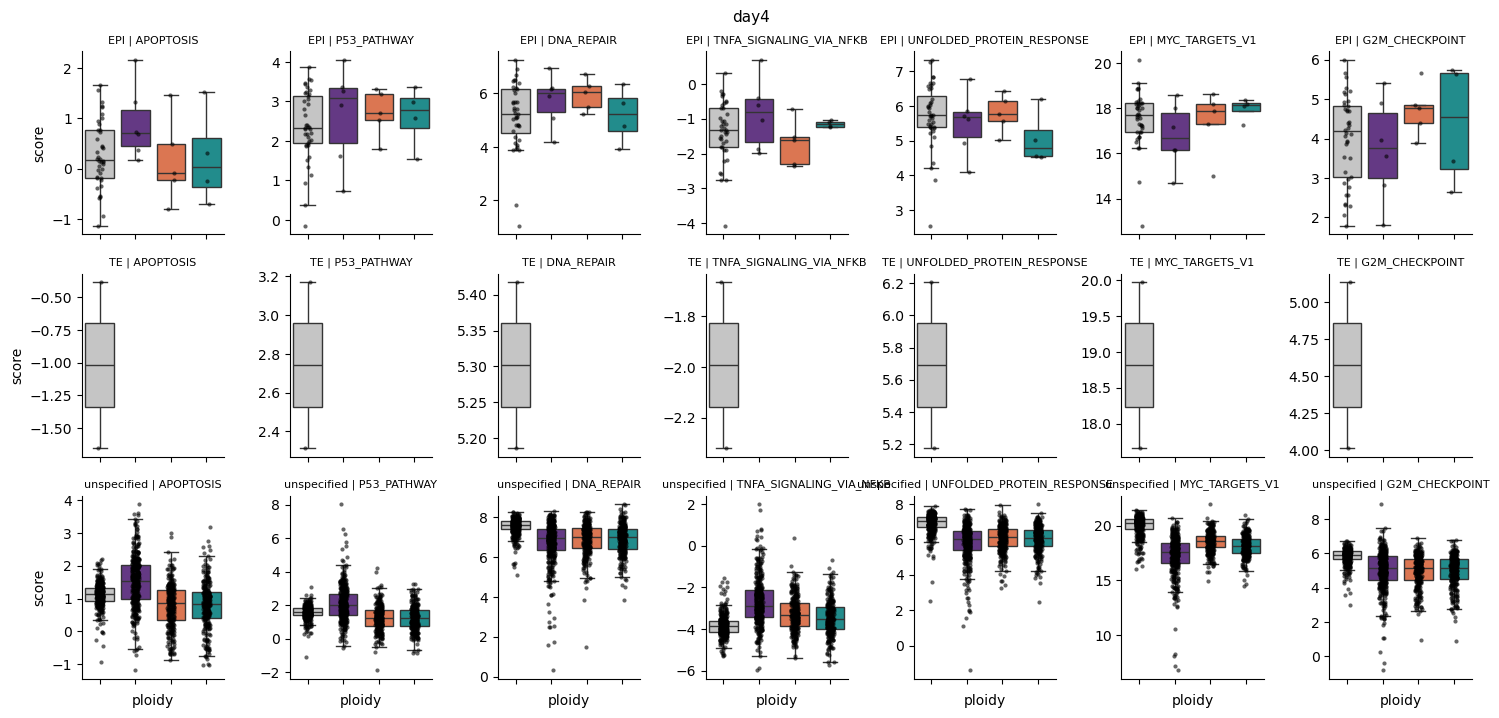

2026-07-13 23:02:45 | [INFO] maxp pruned
2026-07-13 23:02:45 | [INFO] cmap pruned
2026-07-13 23:02:45 | [INFO] kern dropped
2026-07-13 23:02:45 | [INFO] post pruned
2026-07-13 23:02:45 | [INFO] FFTM dropped
2026-07-13 23:02:45 | [INFO] GPOS pruned
2026-07-13 23:02:45 | [INFO] GSUB pruned
2026-07-13 23:02:45 | [INFO] glyf pruned
2026-07-13 23:02:45 | [INFO] Added gid0 to subset
2026-07-13 23:02:45 | [INFO] Added first four glyphs to subset
2026-07-13 23:02:45 | [INFO] Closing glyph list over 'MATH': 53 glyphs before
2026-07-13 23:02:45 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'V', 'W', 'Y', 'a', 'bar', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'i', 'l', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 'three', 'two', 'u', 'underscore', 'y', 'zero']
2026-07-13 23:02:45 | [INFO] Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 25, 26, 27, 

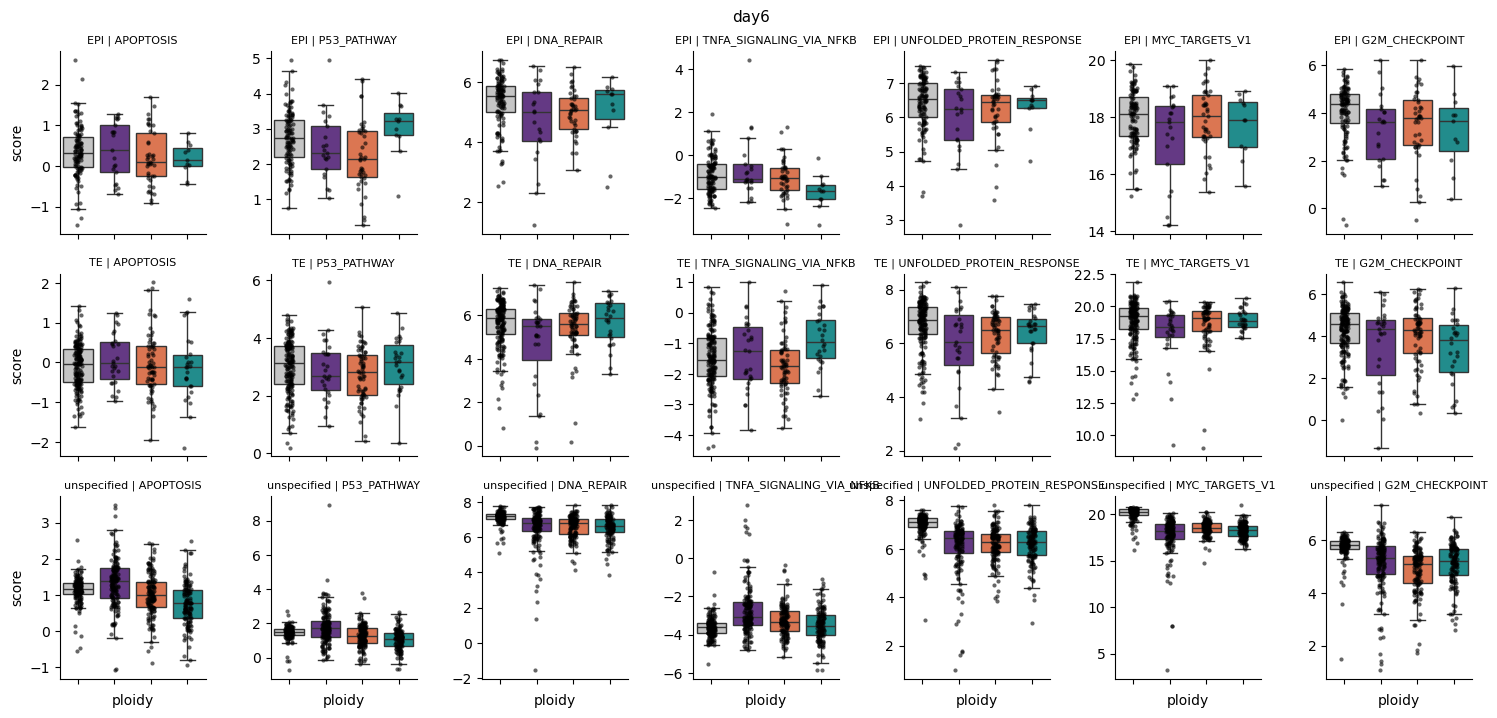

In [81]:
for tp in sorted(long["timepoint"].unique()):
    sub = long[long["timepoint"] == tp]
    g = sns.catplot(data=sub, x="ploidy", y="score", col="pathway", row="celltype",
                    kind="box", palette=palette, height=2.4, aspect=0.9,
                    order=pl_order, fliersize=0, sharey=False)
    g.map_dataframe(sns.stripplot, x="ploidy", y="score",
                    order=pl_order, color="black", size=3, alpha=0.6)
    g.set_titles("{row_name} | {col_name}", size=8)
    g.set_xticklabels(rotation=45, ha="right")
    g.figure.suptitle(tp, y=1.01, fontsize=11)
    g.savefig(f"{fig_dir}/hallmark_mlm_boxplots_{tp}.pdf", bbox_inches="tight")
    plt.show()

## 9. Day1 (no embryo annotation) — fallback

`scBC` does not exist at day1, so a within-embryo paired design is impossible. Options, best first:

1. **If day1 has ≥3 `sample`s per ploidy group** → pseudobulk on `sample` and run the same
   DESeq2 with `~ sample`-free design (`~ ploidy`). Weaker (no pairing) but still replicate-level.
2. **If day1 is effectively 1–2 samples** → there is *no* replication. Do **not** report
   p-values from a cell-level test as if they were valid. Use day1 descriptively (scores,
   effect sizes) and state that it is unreplicated.

The cell below takes route 1 where possible and tells you plainly when it is not.

In [82]:
day1 = adata[(adata.obs["timepoint"] == "day1") & adata.obs["ploidy"].notna()].copy()
day1.obs["pb_group"] = day1.obs["celltype"].astype(str) + "|" + day1.obs["ploidy"].astype(str)

n_samp = day1.obs.groupby(["celltype", "ploidy"], observed=True)["sample"].nunique()
print("Distinct samples per group at day1:\n", n_samp, "\n")

if n_samp.min() >= MIN_SAMPLES_PER_GROUP:
    pdata_d1 = dc.pp.pseudobulk(day1, sample_col="sample", groups_col="pb_group",
                                layer=COUNTS_LAYER, mode="sum",
                                min_cells=MIN_CELLS, min_counts=MIN_COUNTS)
    pdata_d1.obs[["celltype", "ploidy"]] = pdata_d1.obs["pb_group"].str.split("|", expand=True).values
    pdata_d1.obs["embryo"] = pdata_d1.obs["sample"].astype(str)   # so run_deseq's API matches
    print("day1 pseudobulk ready -- rerun run_deseq() on pdata_d1 (it will report paired=False).")
else:
    print(">>> Day1 has too few independent samples for replicate-level DE.")
    print(">>> Report day1 descriptively (activity scores / effect sizes), NOT with p-values.")

Distinct samples per group at day1:
 celltype     ploidy  
EPI          euploid     2
             trisomy     2
             monosomy    2
             complex     2
unspecified  euploid     2
             trisomy     2
             monosomy    2
             complex     2
Name: sample, dtype: int64 

>>> Day1 has too few independent samples for replicate-level DE.
>>> Report day1 descriptively (activity scores / effect sizes), NOT with p-values.


> For a statistically principled version of this (accounting for the compositional constraint
> that fractions sum to 1), run **scCODA** (`pip install sccoda`) on the same per-embryo counts.
> Simple per-group tests on fractions are fine for a first look but are technically
> anti-conservative.

## 11. What was written

```
processed_data/12_pseudobulk_deseq2_gsea/
├── tables/
│   ├── group_sizes.csv                    read this FIRST
│   ├── deseq2_run_log.csv                 which contrasts ran, paired or not, why skipped
│   ├── DESeq2_all_contrasts.csv           main DE table (cis flag included)
│   ├── GSEA_hallmark.csv                  NES, all + trans
│   ├── PROGENy_ulm_contrasts.csv
│   ├── CollecTRI_ulm_contrasts.csv
│   ├── PROGENy_mlm_pseudobulk.csv
│   ├── Hallmark_mlm_pseudobulk.csv
│   ├── hallmark_focus_tests.csv           BH-corrected, replicate-level
│   └── ploidy_composition_per_embryo.csv
└── figures/  (PDF, editable text)
```

### Reading order

1. `group_sizes.csv` + `deseq2_run_log.csv` — **how many embryos actually back each contrast.**
   A contrast with 3 embryos is a hypothesis, not a result.
2. `pseudobulk_PCA.pdf` — if embryo dominates, the paired design was necessary.
3. `DEG_chromosome_enrichment.pdf` — trisomy/monosomy should spike on their own chromosomes.
   This validates the ploidy calls.
4. `volcano_cis_trans.pdf` → `GSEA_hallmark_trans_heatmap.pdf` — the actual result.
5. `hallmark_mlm_boxplots.pdf` — one point per embryo, which is what a reviewer will want.

### Caveats to carry into the write-up

- **`complex` is heterogeneous.** Every complex cell has a different karyotype, so the
  cis/trans split is fuzziest here and the group is the least well-defined biologically.
  Consider stratifying by your `per_complex` / `complexity` variable.
- **Ploidy calls have error.** A misassigned cell dilutes the contrast toward the null; the
  chromosome-enrichment heatmap is your check on call quality.
- **The paired design cannot separate cell-autonomous from non-autonomous effects.** An
  aneuploid cell in a mosaic embryo differs from a euploid neighbour both because of its own
  karyotype and because of competition. To isolate that, compare *euploid cells in mosaic
  embryos vs euploid cells in euploid embryos* — the contrast your original notebook
  gestured at, and the one that would make the elimination story causal.